# Englacial temperature across a glacier profile — advection on vs off

Figures for **slide 7** of the GGMW2026 talk (*The advection term, and where the velocities come from*).

Great Aletsch (RGI7 `02596`), coupled GloGEM–GloGEMflow, BCC-CSM2-MR / ssp126.
Two runs that differ **only** in `enable_advection`:

| member | output directory |
|---|---|
| advection **off** | `icetemp_advfield_aletsch_morteratsch/no_adv/` |
| advection **on**  | `icetemp_advfield_aletsch_morteratsch/adv/` |

### What is plotted

Distance along the flowline on *x*, elevation on *y*, the ice coloured by modelled
englacial temperature, with the ice surface and the bedrock drawn as lines. The bedrock line
itself is coloured by the modelled **basal thermal regime**. A second figure shows the
**advection field** — the *u* and *w* that drive the difference between the two runs.

### Four things to know about the data

1. **The temperature model resolves only the top 259 m.** The column is a fixed 30-layer
   grid (10×1 m, 10×5 m, 10×20 m). Where the ice is thicker the deep ice has no modelled
   temperature and is drawn in neutral grey — and the basal regime there is *unknown*, not
   cold.
2. **These are annual means.** The `temp_field_<id>.dat` and `vel_field_<id>.dat` outputs
   added for these figures average over the twelve months of each year. The older
   `temp_{1m,10m,50m,bedrock}` files store the annual *maximum* — do not mix the two.
3. **Depth labels are the real depths.** Layer centres are 0, 1, … 9, 14, 19, … 59, 79, …
   259 m. The legacy files labelled "10 m" and "50 m" are in fact 14 m and 54 m; this
   notebook reads the true depth axis out of the file header.
4. **Temperate is defined against the pressure melting point, not against 0 °C.** The PMP
   is depth-dependent (−0.173 °C at 259 m), so a fixed 0 °C threshold would miss temperate
   ice at depth.

In [1]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import (Normalize, TwoSlopeNorm, ListedColormap,
                               LinearSegmentedColormap)
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.io import readsav

from cmcrameri import cm as cmc

# ── Styling, matching comparison_aletsch_morteratsch.ipynb ────────────────────
# Arial is not installed on this system; Liberation Sans is metrically identical,
# so it substitutes glyph-for-glyph and the layout is unchanged. Arial is listed
# first so the figures pick it up automatically wherever it *is* installed.
rcParams['font.family']        = 'sans-serif'
rcParams['font.sans-serif']    = ['Arial', 'Liberation Sans', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi']         = 200
rcParams['savefig.dpi']        = 400
rcParams['axes.spines.top']    = False
rcParams['axes.spines.right']  = False
rcParams['axes.labelsize']     = 11
rcParams['legend.framealpha']  = 0.9
rcParams['legend.fontsize']    = 9
rcParams['axes.grid']          = True
rcParams['grid.alpha']         = 0.35
rcParams['grid.linestyle']     = '--'
rcParams['grid.linewidth']     = 0.5

_have_arial = any(f.lower() == 'arial' for f in
                  {f.name for f in __import__('matplotlib.font_manager',
                                              fromlist=['fontManager']).fontManager.ttflist})
print('Arial installed:', _have_arial,
      '(using Liberation Sans, metrically identical)' if not _have_arial else '')

Arial installed: False (using Liberation Sans, metrically identical)


In [2]:
RUN  = Path('/scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development'
            '/icetemp_advfield_aletsch_morteratsch')
GCM, SSP = 'BCC-CSM2-MR', 'ssp126'

# Run pairs. Every pair is (advection on, advection off) and differs in nothing else.
SETUPS = {
    # thermal spin-up off, strain heating off -- the field is still the analytical start
    'baseline': ('adv',        'no_adv',       'no spin-up, no strain heating'),
    'spinup':   ('spinup_adv', 'spinup_noadv', 'thermal spin-up'),
    'strain':   ('strain_adv', 'strain_noadv', 'strain heating'),
    'both':     ('both_adv',   'both_noadv',   'thermal spin-up + strain heating'),
    # same physics as 'both', run on the Aletsch_Gorner catchment
    'aletsch_gorner': ('gorner_adv', 'gorner_noadv', 'thermal spin-up + strain heating'),
    # as 'both', but on the extended 519 m vertical grid (fit_layers = [10,10,23])
    'deep':      ('deep_adv',  'deep_noadv',  'thermal spin-up + strain heating, 519 m column'),
    'gorner_deep': ('gdeep_adv', 'gdeep_noadv', 'thermal spin-up + strain heating, 519 m column'),
}

# RGI7 IDs, verified against geometricdata/rgiv7/files/thick_centraleurope.dat:
GLACIERS = {
    '02596': ('Grosser Aletschgletscher', 'RGI70-11.02596, 81.8 km², 1572–4084 m'),
    # RGI7 01225 is the whole Gorner complex. The flowline the model builds follows its
    # longest, highest branch -- Colle Gnifetti to the tongue -- which is Grenzgletscher,
    # so that is the name on the figures. (The glenglat calibration list uses the outline
    # name 'Gornergletscher' for 01225; same ice, different naming convention.)
    '01225': ('Grenzgletscher',           'RGI70-11.01225, 56.5 km², 2174–4536 m'),
    '02216': ('Vadret da Morteratsch',    'RGI70-11.02216, 18.6 km²'),
}

# Which run pair holds which glacier. Aletsch comes from the Aletsch_Morteratsch
# catchment; Grenz only exists in the Aletsch_Gorner run. Both use the same physics --
# thermal spin-up plus strain heating.
#
# Both now point at the 519 m vertical grid (fit_layers = [10,10,23]), so the two glaciers
# are like-for-like. On the old 259 m grid, 25 of Aletsch's 212 ice-bearing bands were
# thicker than the column and their bed could not be diagnosed at all.
#
# A wedge of roughly one grid layer stays grey directly above the bed, and always will:
# the model solves interior layers to tt-2 and treats tt-1 as a Dirichlet bed node carrying
# the geothermal flux, so the deepest SOLVED value sits one to one-and-a-half layers above
# the ice-rock contact. With 20 m deep spacing that wedge averages 19 m and never exceeds
# 30 m. Shrinking it further is purely a matter of finer deep layers, not of reach.
WHERE = {'02596': 'deep', '01225': 'gorner_deep', '02216': 'baseline'}

# ---- choose what to plot -----------------------------------------------------
GLACIER = '02596'          # '02596' Aletsch  |  '01225' Grenz
SETUP   = WHERE[GLACIER]   # override to compare initialisations on Aletsch:
                           # 'baseline' | 'spinup' | 'strain' | 'both'
# ------------------------------------------------------------------------------

MEMBER_ON, MEMBER_OFF, SETUP_LABEL = SETUPS[SETUP]
NAME, GLACIER_INFO = GLACIERS[GLACIER]

# The flow model only takes over at the inventory date (2004 here), so any year to
# plot must be later than that. 2020 is recent and still has a thick trunk; by 2050
# the whole column is under 259 m and nothing is left unresolved.
#
# 2020 is also entirely inside the reanalysis record: downscale_gcmdata_monthly.pro
# uses ERA5 for every year it covers (through 2025) and only falls back to the
# bias-corrected GCM afterwards. So the plotted field does NOT depend on the GCM or
# the SSP -- those matter only past 2025, and the run extends to 2100 solely because
# ending it earlier would trip settings.pro's `tran[1] lt 2026` rule, which forces
# glacier_retreat='n' and thereby switches the flow model off entirely.
YEAR = 2020
FORCING = 'ERA5 reanalysis'

# Pressure melting point of ice at depth z, as the model applies it
# (procedures/processing/firnice_temperature_model.pro):  pmp = (z*0.9/10)*(-0.00742)
PMP_COEF = 0.9 / 10.0 * -0.00742          # degC per metre of depth
PMP_TOL  = 5e-3                           # degC; within this of the PMP counts as temperate

def pmp(depth):
    """Pressure melting point [degC] at depth [m]."""
    return PMP_COEF * np.asarray(depth, dtype=float)

def member_dir(member):
    return RUN / member / 'monthly' / 'CentralEurope' / 'files' / GCM / SSP

MEMBERS = {'off': MEMBER_OFF, 'on': MEMBER_ON}

def flowgrid_path(member, glacier=None):
    """Locate flowgrid_<id>_flow.sav.

    save_geometry_output.pro builds its output path from the scratch variable `b`,
    which for a future (GCM) run still holds the run's timestamp rather than the
    files/<GCM>/<SSP> path the other writers use -- so the .sav lands in a
    date-stamped sibling directory. Search for it instead of assuming a path.
    """
    glacier = glacier or GLACIER
    root = RUN / member / 'monthly' / 'CentralEurope'
    hits = sorted(root.glob(f'**/flowgrid_{glacier}_flow.sav'))
    if not hits:
        raise FileNotFoundError(f'no flowgrid .sav for {glacier} under {root}')
    return hits[-1]

print(f'{NAME}   {GLACIER_INFO}')
print(f'setup {SETUP}: {SETUP_LABEL}   |   year {YEAR}, forced by {FORCING}')
print(f'PMP at 259 m: {pmp(259):.3f} degC\n')
for k, m in MEMBERS.items():
    print(f'  advection {k:3s} -> {m:12s} temperatures {member_dir(m).exists()}'
          f'   geometry {flowgrid_path(m).name}')

Grosser Aletschgletscher   RGI70-11.02596, 81.8 km², 1572–4084 m
setup deep: thermal spin-up + strain heating, 519 m column   |   year 2020, forced by ERA5 reanalysis
PMP at 259 m: -0.173 degC

  advection off -> deep_noadv   temperatures True   geometry flowgrid_02596_flow.sav
  advection on  -> deep_adv     temperatures True   geometry flowgrid_02596_flow.sav


## 1 — Readers

`temp_field_<id>.dat` and `vel_field_<id>.dat` are written by
`procedures/write/write_firnicetemp_file.pro` under `firnice_write[2] eq 'y'`, one row per
(year, band) the temperature model visited:

```
temp_field:  year  elev_masl  thick_m  n_resolved  T[0..29]
vel_field:   year  elev_masl  n_resolved  u[0..29]  w[0..29]
```

`n_resolved` is the model's `tt`: layers at index `tt-1` and below are the bed node and the
below-bed fill, so everything from `tt-1` down is masked rather than plotted.

In [3]:
def _depth_axis(path):
    """Pull the depth axis out of the '#' header block."""
    header = []
    with Path(path).open() as fh:
        for line in fh:
            if not line.startswith('#'):
                break
            header.append(line)
    for line in reversed(header):
        nums = re.findall(r'-?\d+', line[1:])
        if len(nums) >= 10:
            return np.array([int(v) for v in nums], dtype=float)
    raise ValueError(f'no depth axis found in header of {path}')


def read_temp_field(path):
    """Read temp_field_<id>.dat -> full T(year, band, layer) field."""
    depths = _depth_axis(path)
    raw = np.atleast_2d(np.loadtxt(path, comments='#'))
    nlay = len(depths)
    if raw.shape[1] != 4 + nlay:
        raise ValueError(f'{path}: {raw.shape[1]} columns, expected {4 + nlay}')

    years, elev = raw[:, 0].astype(int), raw[:, 1].astype(int)
    uyears, uelev = np.unique(years), np.unique(elev)
    yi = {y: i for i, y in enumerate(uyears)}
    bi = {e: i for i, e in enumerate(uelev)}

    T  = np.full((len(uyears), len(uelev), nlay), np.nan)
    H  = np.full((len(uyears), len(uelev)), np.nan)
    TT = np.zeros((len(uyears), len(uelev)), dtype=int)
    for r in range(raw.shape[0]):
        a, b = yi[years[r]], bi[elev[r]]
        T[a, b, :] = raw[r, 4:]
        H[a, b]    = raw[r, 2]
        TT[a, b]   = int(raw[r, 3])

    # Keep the bed node. Layer tt-1 carries the geothermal boundary value that the model
    # solves the column against -- it is the modelled basal temperature, and discarding it
    # left a wedge of uncoloured ice directly above the bed. Only tt and below are the
    # below-bed fill (copies of the bed value) and must go.
    #
    # The old code also masked depths > thickness. That is wrong here: tt is chosen as the
    # grid depth NEAREST the ice thickness, so the bed node legitimately sits a few metres
    # below the true bed when the thickness rounds up. tt already encodes where the bed is.
    lay = np.arange(nlay)[None, None, :]
    T[lay >= TT[:, :, None]] = np.nan
    return dict(years=uyears, elev=uelev, depths=depths, T=T, thick=H, n_resolved=TT)


def read_vel_field(path):
    """Read vel_field_<id>.dat -> u and w on the same (year, band, layer) grid."""
    depths = _depth_axis(path)
    raw = np.atleast_2d(np.loadtxt(path, comments='#'))
    nlay = len(depths)
    if raw.shape[1] != 3 + 2 * nlay:
        raise ValueError(f'{path}: {raw.shape[1]} columns, expected {3 + 2*nlay}')

    years, elev = raw[:, 0].astype(int), raw[:, 1].astype(int)
    uyears, uelev = np.unique(years), np.unique(elev)
    yi = {y: i for i, y in enumerate(uyears)}
    bi = {e: i for i, e in enumerate(uelev)}

    U  = np.full((len(uyears), len(uelev), nlay), np.nan)
    W  = np.full((len(uyears), len(uelev), nlay), np.nan)
    TT = np.zeros((len(uyears), len(uelev)), dtype=int)
    for r in range(raw.shape[0]):
        a, b = yi[years[r]], bi[elev[r]]
        U[a, b, :] = raw[r, 3:3 + nlay]
        W[a, b, :] = raw[r, 3 + nlay:]
        TT[a, b]   = int(raw[r, 2])

    lay = np.arange(nlay)[None, None, :]
    bad = lay >= (TT[:, :, None] - 1)
    U[bad] = np.nan
    W[bad] = np.nan
    return dict(years=uyears, elev=uelev, depths=depths, u=U, w=W, n_resolved=TT)


def read_flowgrid(path):
    """Read flowgrid_<id>_flow.sav -> flowline geometry per year."""
    f = readsav(str(path))['flow_hist'][0]
    return dict(
        years = np.asarray(f['years']),
        dist  = np.asarray(f['dist_dx'], dtype=float),   # [m] along flowline
        sur   = np.asarray(f['sur'],   dtype=float),     # [year, cell] surface elevation
        thick = np.asarray(f['thick'], dtype=float),     # [year, cell] ice thickness
        bed   = np.asarray(f['bed_dx'], dtype=float),    # [cell] bedrock elevation
        dx    = int(f['dx']),
    )

In [4]:
fields, grids = {}, {}
for k, m in MEMBERS.items():
    d = member_dir(m)
    fields[k] = read_temp_field(d / 'firnice_temperature' / f'temp_field_{GLACIER}.dat')
    grids[k]  = read_flowgrid(flowgrid_path(m))

# velocities only exist for the run with advection on
vel = read_vel_field(member_dir(MEMBER_ON) / 'firnice_temperature' / f'vel_field_{GLACIER}.dat')

f0, g0 = fields['off'], grids['off']
print(f"years  {f0['years'].min()}-{f0['years'].max()}   bands {len(f0['elev'])}"
      f"  ({f0['elev'].min()}-{f0['elev'].max()} m)   layers {len(f0['depths'])}")
print('depths [m]:', ', '.join(str(int(v)) for v in f0['depths']))
act = np.where((g0['thick'] > 1).any(axis=1))[0]
print(f"\nflowline: {len(g0['dist'])} cells, dx = {g0['dx']} m, "
      f"length {g0['dist'].max()/1000:.2f} km")
print(f"flow model active {g0['years'][act[0]]}-{g0['years'][act[-1]]}")

years  2005-2100   bands 250  (1475-3965 m)   layers 43
depths [m]: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 14, 19, 24, 29, 34, 39, 44, 49, 54, 59, 79, 99, 119, 139, 159, 179, 199, 219, 239, 259, 279, 299, 319, 339, 359, 379, 399, 419, 439, 459, 479, 499, 519

flowline: 125 cells, dx = 130 m, length 16.25 km
flow model active 2004-2100


### Two checks before trusting the figures

**The geometry must be identical between the two members.** Englacial temperature is a
diagnostic in this version — it does not feed the flow law or the sliding factor — so
turning advection on must not move a single grid cell. If it did, the difference panel would
be part geometry and part thermodynamics.

**The new field must agree with the output that already existed.** `temp_field` stores the
annual *mean*; `temp_10m` stores the annual *maximum* at the same layer (real depth 14 m).
The mean can never exceed the maximum, and the two should track each other closely.

In [5]:
geom_same = all(np.array_equal(np.asarray(grids['off'][k], float),
                               np.asarray(grids['on'][k], float))
                for k in ('sur', 'thick', 'bed', 'dist'))
print(f'geometry identical between members: {geom_same}')
assert geom_same, 'advection changed the geometry - the difference panel would be uninterpretable'

def read_legacy_slice(member, name):
    p = member_dir(member) / 'firnice_temperature' / f'{name}_{GLACIER}.dat'
    yrs = np.array([int(v) for v in p.open().readline().split()[1:]])
    d = np.loadtxt(p, skiprows=1)
    return yrs, d[:, 0].astype(int), d[:, 1:]

lyrs, lelev, L = read_legacy_slice(MEMBER_ON, 'temp_10m')
li = int(np.where(lyrs == YEAR)[0][0])
fa, ya = fields['on'], int(np.where(fields['on']['years'] == YEAR)[0][0])
shared = np.intersect1d(lelev, fa['elev'])
new = fa['T'][ya][np.searchsorted(fa['elev'], shared), 10]
old = L[np.searchsorted(lelev, shared), li]
ok = (old > -98) & np.isfinite(new)

print(f'14 m slice, {YEAR}, {ok.sum()} bands  (annual mean vs annual max)')
print(f'  max(mean - max) = {np.max(new[ok]-old[ok]):+.3f}  (must be <= 0)')
print(f'  mean difference = {np.mean(new[ok]-old[ok]):+.3f}')
print(f'  correlation     = {np.corrcoef(new[ok], old[ok])[0,1]:.4f}')
assert np.max(new[ok] - old[ok]) <= 1e-3, 'annual mean exceeds annual max somewhere'

geometry identical between members: True
14 m slice, 2020, 212 bands  (annual mean vs annual max)
  max(mean - max) = -0.012  (must be <= 0)
  mean difference = -0.115
  correlation     = 0.9964


## 2 — Map the band columns onto the flowline

The temperature model works on elevation bands; the flow model works on an equidistant
horizontal grid. Slide 7 describes the join as *"interpolated on surface elevation"*, and
that is what happens here: each flowline cell takes the column of the band whose elevation
is closest to that cell's **surface** elevation, then the column is interpolated from
depth-below-surface onto absolute elevation.

Three masks come out of it, and they mean different things:

* **`values`** — what the model solved. Coloured.
* **`homologous`** — the same field minus the pressure melting point at that depth,
  T − T_pmp. Zero exactly at the melting point, negative for cold ice.
* **`temperate`** — solved ice sitting at the pressure melting point. Coloured red.
* **`unresolved`** — ice lying beyond the model grid entirely. Grey, never coloured. With
  the 519 m column this no longer occurs on Alpine glaciers.

The coloured field runs all the way to the bed: the profile includes the bed node and is held
over the last fraction of a layer to the ice-rock contact. The **basal regime** is read from
the deepest *interior* layer instead, because the bed node is clamped to the melting point by
construction and would report "temperate" everywhere.

In [6]:
def cross_section(field, grid, year, key='T', dy=5.0, temperate_from=None):
    """Build a (distance x elevation) section of `field[key]` for one year."""
    fy = np.where(field['years'] == year)[0]
    gy = np.where(grid['years']  == year)[0]
    if not len(fy) or not len(gy):
        raise ValueError(f'year {year} not present in both files')
    fy, gy = int(fy[0]), int(gy[0])

    sur   = grid['sur'][gy]
    thick = grid['thick'][gy]
    bed   = sur - thick
    has   = thick > 1.0
    if not has.any():
        raise ValueError(f'no ice on the flowline in {year}')

    bed_line = np.where(has, bed, grid['bed'])
    sur_line = np.where(has, sur, grid['bed'])

    yaxis = np.arange(np.floor(bed_line.min() / dy) * dy,
                      np.ceil(sur_line.max() / dy) * dy + dy, dy)
    nx, ny = len(sur), len(yaxis)

    V    = np.full((ny, nx), np.nan)
    TEMP = np.zeros((ny, nx), dtype=bool)
    unr  = np.zeros((ny, nx), dtype=bool)
    # Two different reasons a cell can end up uncoloured, which the legend used to conflate:
    #   nocol  - the elevation band this flowline cell maps to has no solved column at all
    #   beyond - the ice is deeper than the model grid (does not occur with the 519 m column)
    nocol = np.zeros(nx, dtype=bool)
    depth_of = np.full((ny, nx), np.nan)

    bands, depths = field['elev'], field['depths']
    src   = field[key]
    tsrc  = field[temperate_from] if temperate_from else None

    # deepest resolved layer per band -> the basal diagnosis
    bed_T     = np.full(nx, np.nan)
    bed_depth = np.full(nx, np.nan)

    for k in np.where(has)[0]:
        b   = int(np.argmin(np.abs(bands - sur[k])))
        col = src[fy, b, :]
        ok  = np.isfinite(col)
        inside = (yaxis <= sur[k]) & (yaxis >= bed[k])
        idx = np.where(inside)[0]
        if not ok.any():
            unr[idx, k] = True
            nocol[k] = True
            continue
        d_ok = depths[ok]
        depth = sur[k] - yaxis[inside]
        # Hold the bed-node value over the last fraction of a layer down to the true bed.
        # The model placed its bed at the nearest grid depth, so this closes a gap of at
        # most half a layer (<= ~10 m) at ~0.02 degC/m -- a discretisation statement, not
        # missing data. Ice is only flagged unresolved when it lies beyond the grid itself.
        vals = np.interp(depth, d_ok, col[ok], left=col[ok][0], right=col[ok][-1])
        beyond = depth > depths.max()
        vals[beyond] = np.nan
        V[idx, k] = vals
        depth_of[idx, k] = depth
        unr[idx[beyond], k] = True

        if tsrc is not None:
            tcol = tsrc[fy, b, :]
            tvals = np.interp(depth, d_ok, tcol[ok], left=tcol[ok][0], right=tcol[ok][-1])
            TEMP[idx, k] = (tvals >= pmp(depth) - PMP_TOL) & ~beyond
            # Basal regime is read from the deepest INTERIOR layer (tt-2), not from the
            # bed node (tt-1). The bed node is set as min(geothermal value, PMP) and comes
            # out clamped exactly on the melting point for 100 % of Aletsch's bands in both
            # members -- so it reports "temperate" everywhere regardless of the physics and
            # cannot distinguish the advection runs. The deepest solved layer sits one to
            # one-and-a-half grid layers higher but is an actual thermodynamic state.
            ttb = int(field['n_resolved'][fy, b])
            if ttb > 2:
                bed_T[k]     = tsrc[fy, b, ttb - 2]
                bed_depth[k] = depths[ttb - 2]

    # Homologous temperature: T minus the pressure melting point at that depth. Zero
    # means temperate whatever the overburden, so the cold/temperate structure reads
    # directly off the colour rather than having to be inferred from a mask.
    homol = V - pmp(depth_of) if temperate_from else None

    # ---- surface-following grid -------------------------------------------------
    # On a common elevation axis the ice band is (ice thickness)/(elevation range) of the
    # panel height -- for Grenz ~60 m out of 2260 m, under 3 %. That ratio is fixed by the
    # glacier and no amount of vertical exaggeration changes it: squeezing x makes the
    # profile steeper, not the ice thicker. Re-gridding on depth below the surface removes
    # the elevation range from the y axis entirely and lets the ice fill the panel.
    dmax = float(np.ceil(thick[has].max() / 10.0) * 10.0)
    daxis = np.arange(0.0, dmax + dy, dy)
    Vd   = np.full((len(daxis), nx), np.nan)
    TEMPd = np.zeros((len(daxis), nx), dtype=bool)
    unrd  = np.zeros((len(daxis), nx), dtype=bool)
    for k in np.where(has)[0]:
        b   = int(np.argmin(np.abs(bands - sur[k])))
        col = src[fy, b, :]
        ok  = np.isfinite(col)
        inside = daxis <= thick[k]
        idx = np.where(inside)[0]
        if not ok.any():
            unrd[idx, k] = True
            continue
        d_ok = depths[ok]
        vals = np.interp(daxis[inside], d_ok, col[ok], left=col[ok][0], right=col[ok][-1])
        beyond = daxis[inside] > depths.max()
        vals[beyond] = np.nan
        Vd[idx, k] = vals
        unrd[idx[beyond], k] = True
        if tsrc is not None:
            tcol = tsrc[fy, b, :]
            tv = np.interp(daxis[inside], d_ok, tcol[ok], left=tcol[ok][0], right=tcol[ok][-1])
            TEMPd[idx, k] = (tv >= pmp(daxis[inside]) - PMP_TOL) & ~beyond

    return dict(dist=grid['dist'] / 1000.0, y=yaxis,
                d_axis=daxis, d_values=np.ma.masked_invalid(Vd),
                d_homologous=np.ma.masked_invalid(Vd - pmp(daxis)[:, None]) if temperate_from else None,
                d_temperate=TEMPd, d_unresolved=unrd, no_column=nocol,
                values=np.ma.masked_invalid(V),
                homologous=np.ma.masked_invalid(homol) if homol is not None else None,
                temperate=TEMP, unresolved=unr,
                depth=depth_of, sur=sur_line, bed=bed_line, has_ice=has,
                ice_thick=thick, bed_T=bed_T, bed_depth=bed_depth,
                max_depth=float(depths.max()), year=year)


def basal_regime(sec):
    """Classify each flowline cell's bed: 1 temperate, 0 cold, -1 not resolved.

    The model column stops at 259 m. Where the ice is thicker than that, the deepest
    solved layer is NOT the bed, so no basal claim can be made there.
    """
    reg = np.full(len(sec['dist']), -1, dtype=int)
    known = sec['has_ice'] & (sec['ice_thick'] <= sec['max_depth']) & np.isfinite(sec['bed_T'])
    reg[known] = (sec['bed_T'][known] >= pmp(sec['bed_depth'][known]) - PMP_TOL).astype(int)
    return reg


sections = {m: cross_section(fields[m], grids[m], YEAR, key='T', temperate_from='T')
            for m in ('off', 'on')}
vel_sec  = {k: cross_section(vel, grids['on'], YEAR, key=k) for k in ('u', 'w')}

s = sections['on']
solved = (~s['values'].mask).sum()
print(f"{YEAR}: grid {s['values'].shape[1]} x {s['values'].shape[0]}"
      f"   T range {s['values'].min():.2f} .. {s['values'].max():.2f} degC")
print(f"resolved ice cells: {100*solved/(solved+s['unresolved'].sum()):.1f}%"
      f"   temperate among them: {100*s['temperate'].sum()/solved:.1f}%")
for m in ('off', 'on'):
    r = basal_regime(sections[m])
    ice = sections[m]['has_ice']
    print(f"  {m:7s} bed: {np.sum(r==1):3d} temperate, {np.sum(r==0):3d} cold, "
          f"{np.sum((r==-1) & ice):3d} too thick to say  (of {ice.sum()} ice cells)")

2020: grid 125 x 615   T range -4.20 .. -0.02 degC
resolved ice cells: 98.6%   temperate among them: 17.3%
  off     bed:  83 temperate,   2 cold,   4 too thick to say  (of 89 ice cells)
  on      bed:  61 temperate,  24 cold,   4 too thick to say  (of 89 ice cells)


## 3 — Colours

One colour language across every panel: **blue is cold, red is warm.**

* **Ice temperature** — a continuous ramp through the cold half of `cmc.vik`
  (`vik(0.0 → 0.46)`), dark blue for the coldest ice, pale blue towards the melting point.
  Ice that has reached the pressure melting point is painted in `vik(0.95)` red, set as the
  colormap's *over* colour, so it appears as a red cap on the colourbar and temperate ice
  cannot be mistaken for merely warm ice.

  On Aletsch in 2020 only a few per cent of the *ice* is temperate, but a third of the
  *bed* is — which is why the bedrock line is colour-coded on the same red/blue scale. That
  line, not the fill, is where the polythermal structure shows.
* **The difference panel** — full `cmc.vik`, neutral at zero: blue where advection cools the
  ice, red where it warms it.
* **The advection field** — deliberately different families so velocity is never confused
  with temperature: `cmc.batlow` for horizontal speed (a magnitude), `cmc.bam` for the
  vertical velocity (a signed quantity, and no blue or red in it).

In [7]:
def vik_icetemp_cmap(n=256, cold_hi=0.46):
    """Continuous cold ramp from cmc.vik, with vik(0.95) red as the 'over' colour.

    cold_hi stops at 0.46, just short of vik's white midpoint at 0.50. Running to 0.55
    (as a discrete level scheme would) pushes the top of the ramp onto vik's warm side,
    so the warmest *cold* ice comes out pale orange and competes with the red that is
    supposed to mean temperate. Warm hues stay reserved for the melting point.

    Discrete equivalent, if you ever want banded levels instead:
        blue   = cmc.vik(np.linspace(0.0, cold_hi, n_int - 1))
        red    = np.array(cmc.vik(0.95)).reshape(1, -1)
        cmap   = ListedColormap(np.vstack([blue, red]))
    """
    cmap = LinearSegmentedColormap.from_list(
        'icetemp_vik', cmc.vik(np.linspace(0.0, cold_hi, n)))
    cmap = cmap.copy()
    cmap.set_over(cmc.vik(0.95))     # temperate ice
    cmap.set_bad(alpha=0.0)          # no ice / not solved -> transparent
    return cmap

CMAP_T    = vik_icetemp_cmap()
CMAP_DIFF = cmc.vik
CMAP_U    = cmc.batlow
CMAP_W    = cmc.bam

COL_TEMPERATE = cmc.vik(0.95)        # red   - at the pressure melting point
COL_COLD      = cmc.vik(0.15)        # blue  - below it
GREY_ICE      = '#c9ccd1'            # ice deeper than the model column
GREY_ROCK     = '#d3cfc8'            # bedrock body
GREY_UNKNOWN  = '#9aa0a6'            # bed regime not resolvable
INK           = '#22252a'
INK_SOFT      = '#5f6672'

print('temperate red :', tuple(round(v, 3) for v in COL_TEMPERATE))
print('cold blue     :', tuple(round(v, 3) for v in COL_COLD))

temperate red : (np.float64(0.429), np.float64(0.062), np.float64(0.027), np.float64(1.0))
cold blue     : (np.float64(0.015), np.float64(0.304), np.float64(0.529), np.float64(1.0))


## 4 — The temperature figure

Three stacked panels sharing one *x* axis and one temperature scale:

* **(a)** advection off — conduction and latent heat only
* **(b)** advection on — the same run with `enable_advection = 'y'`
* **(c)** the difference, (b) − (a)

Framing decisions worth knowing about:

* The view is cropped to the **glaciated part of the flowline**, and the panels are made
  tall on purpose. Aletsch is 16 km long and a few hundred metres thick, so on a true-scale
  axis the ice is a hairline. The vertical exaggeration is printed in the corner — raise
  `figsize[1]` to stretch it further.
* The **bedrock line is colour-coded** by modelled basal thermal regime. Where the ice is
  thicker than the 259 m column the bed is beyond the model's reach, so that stretch is
  drawn grey rather than claimed as cold.
* The difference scale is set from a **percentile**, not the extreme value. A single band
  near the firn line swings by almost 6 °C; letting it set the range flattens everything
  else to white. Values beyond the range keep the end colour and the colourbar is drawn
  with arrows to say so.

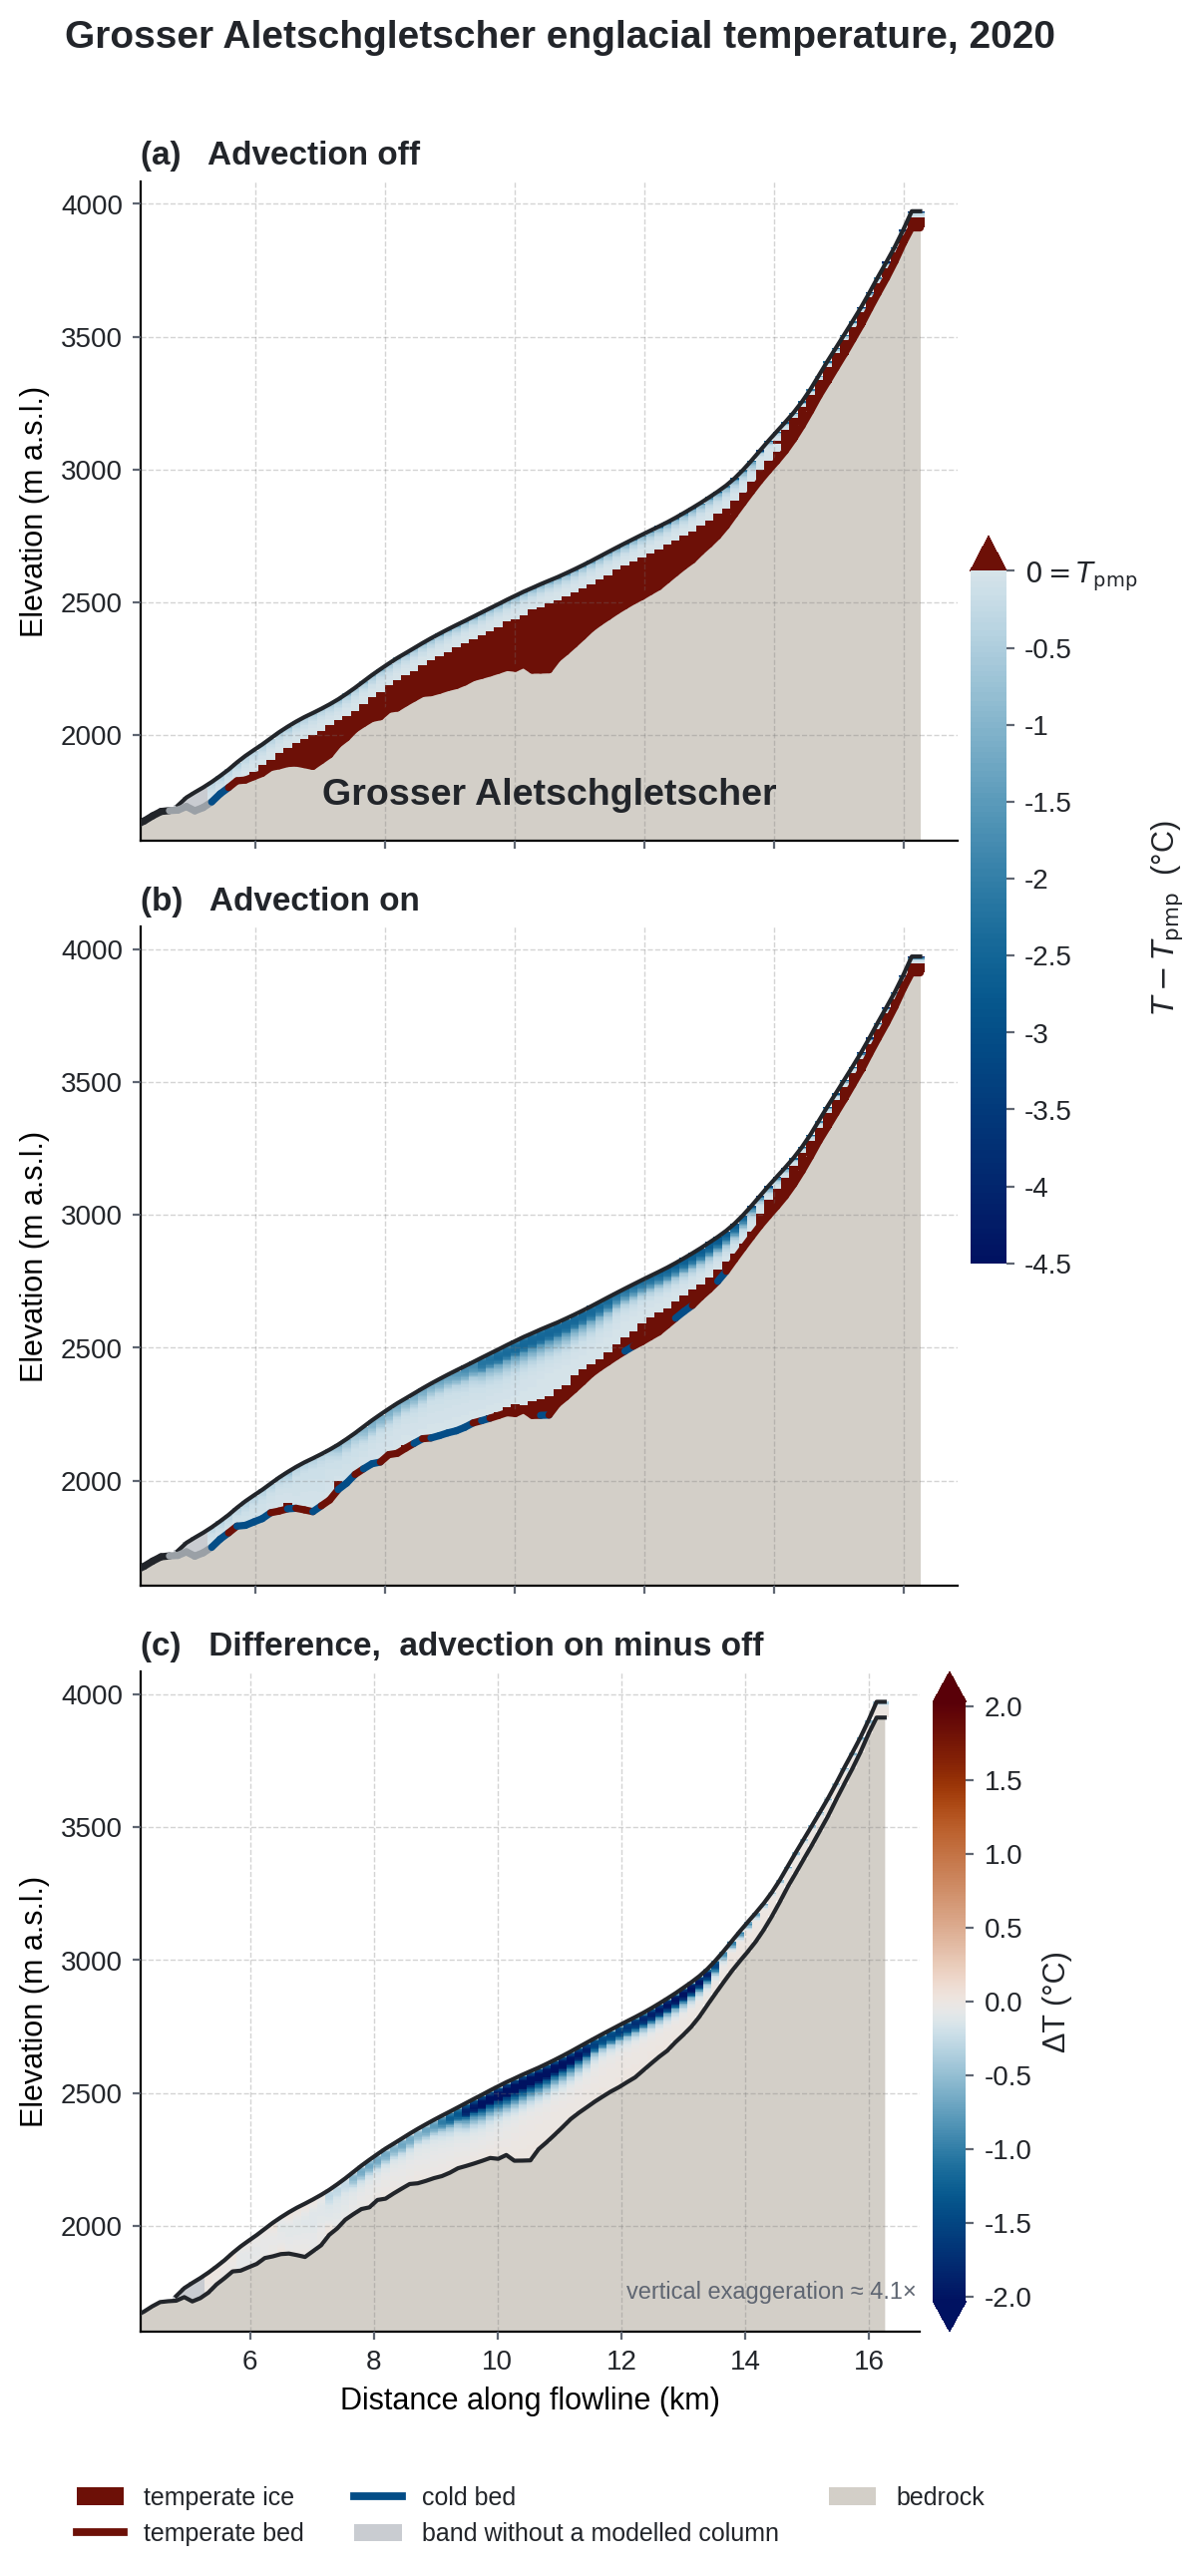

In [8]:
def draw_bed(ax, sec, lw=2.6, zorder=6):
    """Bedrock line, coloured by modelled basal thermal regime."""
    x, bed = sec['dist'], sec['bed']
    reg = basal_regime(sec)
    cols = {1: COL_TEMPERATE, 0: COL_COLD, -1: GREY_UNKNOWN}
    pts = np.column_stack([x, bed]).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    # a segment takes the regime of its warmer/better-known end
    seg_reg = np.where(sec['has_ice'][:-1], reg[:-1], reg[1:])
    seg_col = [cols[int(r)] if sec['has_ice'][i] or sec['has_ice'][i+1] else INK
               for i, r in enumerate(seg_reg)]
    ax.add_collection(LineCollection(segs, colors=seg_col, linewidths=lw,
                                     zorder=zorder, capstyle='round'))


def draw_section(ax, sec, values, cmap, norm, ylim, show_unresolved=True,
                 temperate=None, bed_regime=True):
    """Paint one cross-section panel: bedrock, ice, surface and bed lines."""
    x, y = sec['dist'], sec['y']
    ice = sec['has_ice']

    ax.fill_between(x, ylim[0], sec['bed'], color=GREY_ROCK, zorder=0, linewidth=0)

    if show_unresolved and sec['unresolved'].any():
        grey = np.ma.masked_where(~sec['unresolved'], np.ones_like(sec['unresolved'], float))
        ax.pcolormesh(x, y, grey, cmap=ListedColormap([GREY_ICE]),
                      vmin=0, vmax=1, shading='nearest', zorder=1)

    plotted = values
    if temperate is not None:
        # push temperate cells past vmax so the colormap's 'over' colour renders them;
        # the colourbar shows that colour as a labelled cap
        plotted = np.ma.where(temperate, norm.vmax + 1.0, values)

    mesh = ax.pcolormesh(x, y, plotted, cmap=cmap, norm=norm, shading='nearest', zorder=2)

    # gridlines above the fills, faint enough not to compete with the data
    ax.grid(True, which='major', color='0.45', alpha=0.30, ls='--', lw=0.5, zorder=3.5)
    ax.set_axisbelow(False)

    ax.plot(x[ice], sec['sur'][ice], color=INK, lw=1.5, zorder=6)      # ice surface
    if bed_regime:
        draw_bed(ax, sec)
    else:
        ax.plot(x, sec['bed'], color=INK, lw=1.5, zorder=6)

    ax._sec_dist, ax._sec_bed, ax._sec_ice = x, sec['bed'], ice
    ax.set_ylim(*ylim)
    ax.set_ylabel('Elevation (m a.s.l.)')
    ax.tick_params(colors=INK_SOFT, labelcolor=INK, length=3)
    return mesh


def _frame(secs, pad_frac=0.05):
    """Crop to the glaciated flowline, shared by every panel."""
    ice = secs[0]['has_ice']
    xlo = min(s['dist'][s['has_ice']].min() for s in secs)
    xhi = max(s['dist'][s['has_ice']].max() for s in secs)
    ylo = min(s['bed'][s['has_ice']].min() for s in secs)
    yhi = max(s['sur'][s['has_ice']].max() for s in secs)
    xp, yp = pad_frac * (xhi - xlo), pad_frac * (yhi - ylo)
    return (xlo - xp, xhi + xp), (ylo - yp, yhi + yp)


def _exaggeration(fig, ax, xlim, ylim):
    fig.canvas.draw()
    bb = ax.get_window_extent()
    return (((xlim[1] - xlim[0]) * 1000.0) / bb.width) / ((ylim[1] - ylim[0]) / bb.height)


def _regime_legend(ax, sec, drop=0.20):
    """Legend hung below the bottom panel, clear of its x-label and of the sections.

    Anchored to the axes rather than the figure so bbox_inches='tight' always keeps it;
    a figure-coordinate placement lands on top of the tick labels instead.
    """
    reg = basal_regime(sec)
    handles = [Patch(facecolor=COL_TEMPERATE, edgecolor='none', label='temperate ice')]
    handles += [Line2D([], [], color=c, lw=2.8, label=t) for c, t, on in
                [(COL_TEMPERATE, 'temperate bed', (reg == 1).any()),
                 (COL_COLD,      'cold bed',      (reg == 0).any())] if on]

    # Grey used to be labelled "below the 259 m model column". With the 519 m grid no
    # Alpine ice reaches past the column, and the cells that stay grey are the opposite
    # case: thin marginal cells (18-78 m here) whose nearest elevation band has no solved
    # temperature column at all. Name each cause for what it is, and only when it occurs.
    if sec.get('no_column') is not None and sec['no_column'].any():
        handles.append(Patch(facecolor=GREY_ICE, edgecolor='none',
                             label='band without a modelled column'))
    beyond = sec['unresolved'].any(axis=0) & ~(sec.get('no_column')
                                               if sec.get('no_column') is not None
                                               else np.zeros(len(sec['dist']), bool))
    if beyond.any():
        handles.append(Patch(facecolor=GREY_ICE, edgecolor='none',
                             label=f'ice deeper than the {int(sec["max_depth"])} m model column'))
    handles.append(Patch(facecolor=GREY_ROCK, edgecolor='none', label='bedrock'))
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, drop * -1),
              ncol=3, fontsize=9, frameon=False, labelcolor=INK, handlelength=1.9,
              columnspacing=2.0)


def _label_pmp_tick(cb, view):
    """In the homologous view, zero is the melting point, not 0 degC.

    T - T_pmp = 0 means the ice is AT the pressure melting point, which is -0.17 degC at
    259 m depth and only approaches 0 degC at the surface. A bare "0.0" invites exactly the
    misreading this view exists to prevent, so the zero tick is named.
    """
    if view != 'homologous':
        return
    cb.ax.figure.canvas.draw()
    ticks = list(cb.get_ticks())
    if not any(abs(t) < 1e-9 for t in ticks):
        ticks = sorted(set(ticks + [0.0]))
    cb.set_ticks(ticks)
    cb.set_ticklabels([r'$0=T_\mathrm{pmp}$' if abs(t) < 1e-9 else f'{t:g}' for t in ticks])


def _label_glacier(ax, name, x_frac=0.5, buffer=0.07, weight='bold', size=13.5):
    """Name the glacier in the bedrock, just above the x axis.

    Positioned a fixed fraction of the axis height above the bottom spine, so it sits in
    the same place whether the y axis is elevation (increasing upward) or depth below the
    surface (increasing downward) -- get_ylim()[0] is the bottom of the axes either way.
    A cropped single panel then still identifies itself once the figure title is gone.
    """
    (x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
    xc = x0 + x_frac * (x1 - x0)
    yc = y0 + buffer * (y1 - y0)
    ax.text(xc, yc, name, ha='center', va='center', fontsize=size,
            fontweight=weight, color=INK, zorder=7)


def _titles(fig, title, top=0.925):
    """Centred title, set close to the panels.

    Run provenance (spin-up, forcing, scenario) is deliberately not printed here -- it
    belongs on the slide around the figure, not inside it.
    """
    fig.text(0.5, top, title, ha='center', va='bottom',
             fontsize=14, fontweight='bold', color=INK)


# 'absolute'   -> T in degC; the melting point sits at a different value at every depth
# 'homologous' -> T - T_pmp; zero is the melting point everywhere, so cold and temperate
#                 ice are separated by the colour itself and not only by the red mask
TEMPERATURE_VIEW = 'homologous'

def advection_figure(sections, year, name=None, figsize=(5.6, 14.0), diff_pct=98.0,
                     view=None):
    # resolved here, not in the signature: a `name=NAME` default binds once, when the def
    # runs, so later reassignments of NAME never reach it
    name = name or NAME
    view = view or TEMPERATURE_VIEW
    key  = 'homologous' if view == 'homologous' else 'values'
    off, on = sections['off'], sections['on']
    # The pressure melting point depends only on depth, so it cancels in the difference:
    # panel (c) is identical in either view.
    diff = on['values'] - off['values']
    xlim, ylim = _frame([off, on])

    tmin = float(min(off[key].min(), on[key].min()))
    norm_t = Normalize(vmin=np.floor(tmin * 2) / 2, vmax=0.0)

    finite = np.abs(diff.compressed())
    lim = max(round(float(np.percentile(finite, diff_pct)), 2), 0.05) if finite.size else 0.1
    norm_d = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True,
                             gridspec_kw=dict(hspace=0.13))

    m1 = draw_section(axes[0], off, off[key], CMAP_T, norm_t, ylim,
                      temperate=off['temperate'])
    draw_section(axes[1], on, on[key], CMAP_T, norm_t, ylim,
                 temperate=on['temperate'])
    m2 = draw_section(axes[2], on, diff, CMAP_DIFF, norm_d, ylim, bed_regime=False)
    axes[0].set_xlim(*xlim)

    for ax, t in zip(axes, ['(a)   Advection off',
                            '(b)   Advection on',
                            '(c)   Difference,  advection on minus off']):
        ax.set_title(t, loc='left', fontsize=12, fontweight='bold', color=INK, pad=6)
    axes[-1].set_xlabel('Distance along flowline (km)')

    # extend='max' draws the temperate colour as a red cap; it is named in the legend
    # rather than lettered on the bar, where it would sit on top of the arrow.
    cb0 = fig.colorbar(m1, ax=axes[:2], pad=0.015, fraction=0.042, extend='max')
    cb0.set_label('$T - T_\mathrm{pmp}$  (°C)' if view == 'homologous'
                  else 'Englacial temperature (°C)', color=INK)
    _label_pmp_tick(cb0, view)
    cb2 = fig.colorbar(m2, ax=[axes[2]], pad=0.015, fraction=0.085, extend='both')
    cb2.set_label('ΔT (°C)', color=INK)
    for cb in (cb0, cb2):
        cb.outline.set_visible(False)
        cb.ax.tick_params(colors=INK_SOFT, labelcolor=INK, length=3)

    _regime_legend(axes[2], off)
    _label_glacier(axes[0], name)
    _titles(fig, f'{name} englacial temperature, {year}')

    vex = _exaggeration(fig, axes[0], xlim, ylim)
    axes[2].annotate(f'vertical exaggeration ≈ {vex:.1f}×', xy=(0.995, 0.05),
                     xycoords='axes fraction', ha='right', fontsize=8.5, color=INK_SOFT)
    return fig, axes


fig, axes = advection_figure(sections, YEAR)
plt.show()

## 5 — The advection field

The velocities that make panel (c) look the way it does, on the same cross-section:

* **(a)** *u*, the depth-averaged SIA speed reshaped by the Nye profile
  `u(ζ)/ū = (1 − ζ⁴) / 0.8`, ζ = depth / column depth. Fast through most of the column, with
  the shear concentrated near the bed.
* **(b)** *w*, the kinematic vertical velocity, **downward positive** — burial in the
  accumulation area, emergence in the ablation area — tapering linearly to zero at the bed.

Both are written by the run with advection on, and both inherit the model's own limits: no
velocity above the topmost band (nothing upglacier to advect from) and nothing below
259 m.

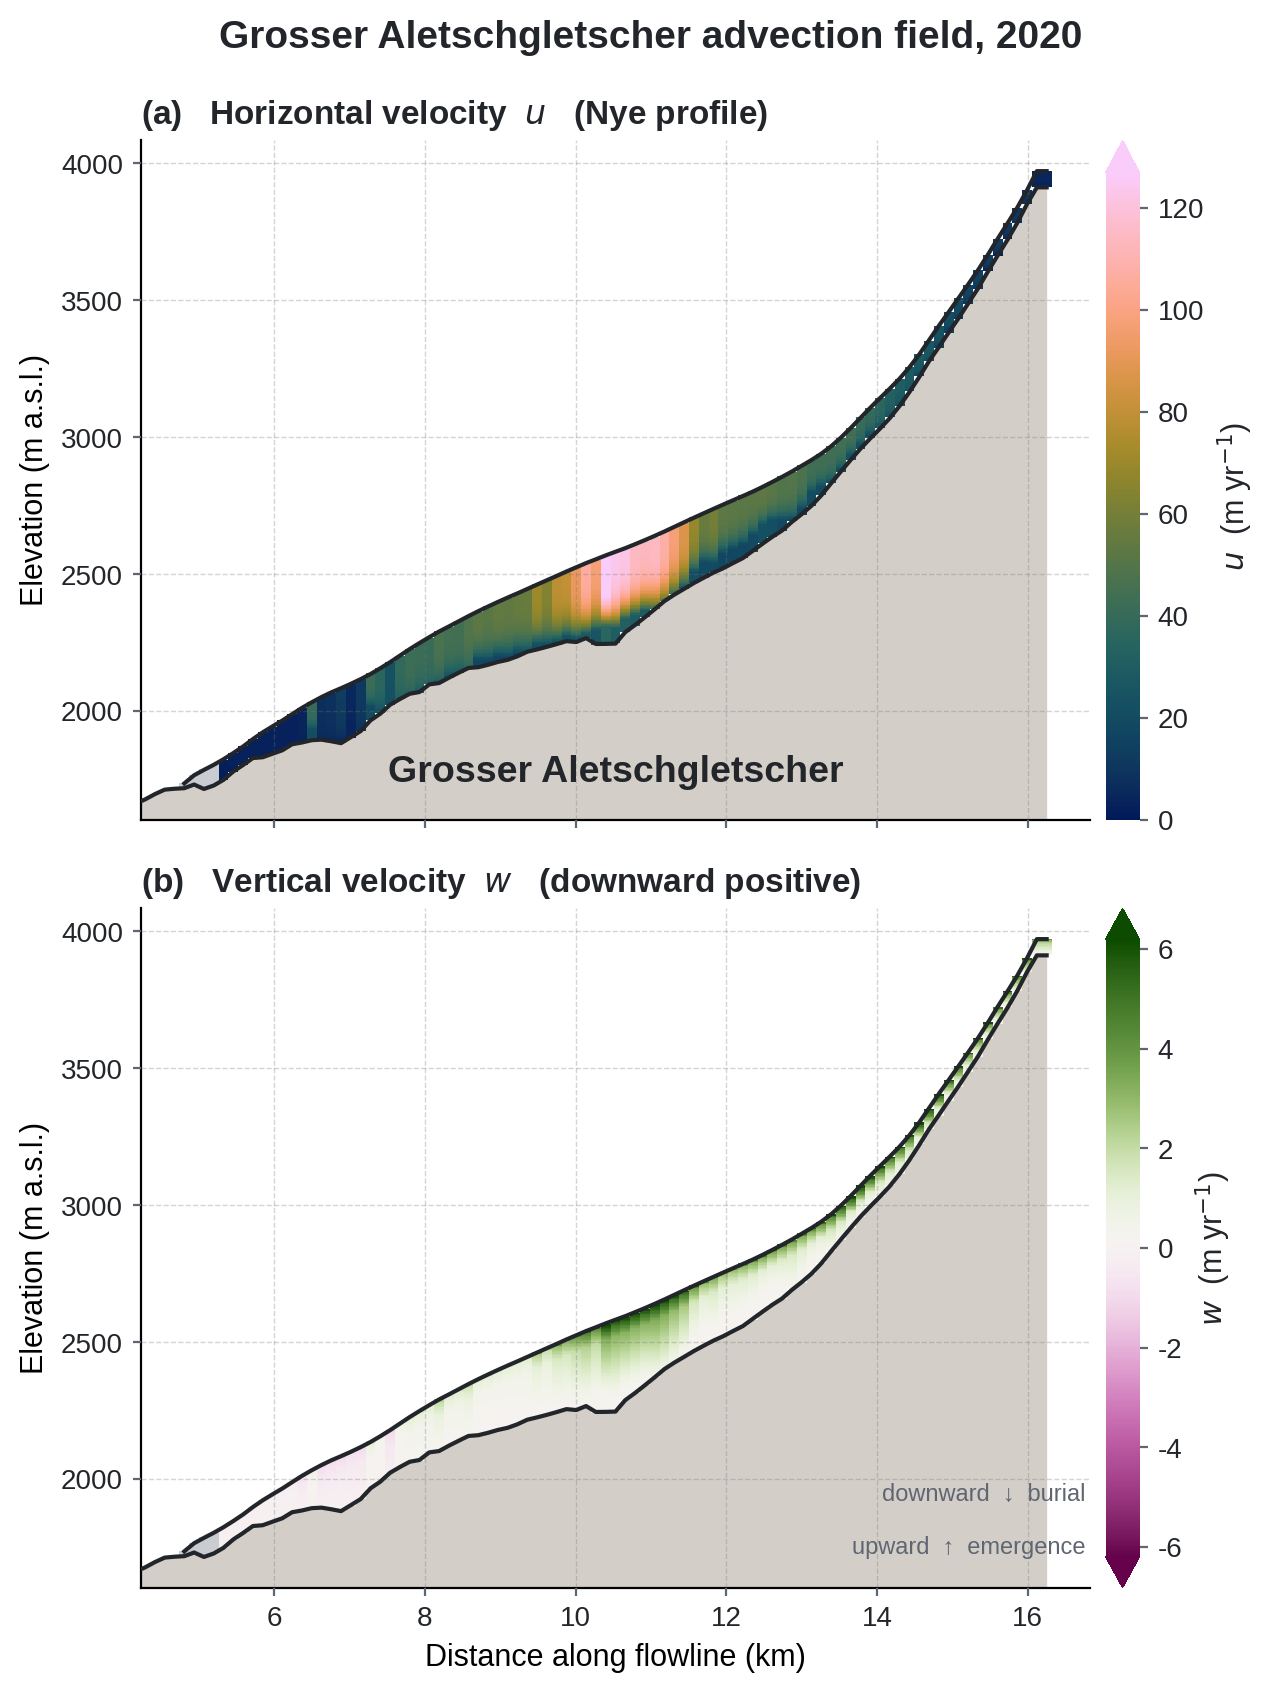

In [9]:
def velocity_figure(vel_sec, sections, year, name=None, figsize=(6.8, 9.4)):
    name = name or NAME          # see advection_figure: a NAME default binds at def time
    su, sw = vel_sec['u'], vel_sec['w']
    xlim, ylim = _frame([sections['on']])

    umax = float(np.nanpercentile(su['values'].compressed(), 99)) if su['values'].count() else 1.0
    norm_u = Normalize(vmin=0.0, vmax=max(round(umax, 1), 0.1))
    wlim = float(np.nanpercentile(np.abs(sw['values'].compressed()), 99)) if sw['values'].count() else 1.0
    norm_w = TwoSlopeNorm(vmin=-max(round(wlim, 2), 0.05), vcenter=0.0,
                          vmax=max(round(wlim, 2), 0.05))

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True,
                             gridspec_kw=dict(hspace=0.13))
    mu = draw_section(axes[0], su, su['values'], CMAP_U, norm_u, ylim, bed_regime=False)
    mw = draw_section(axes[1], sw, sw['values'], CMAP_W, norm_w, ylim, bed_regime=False)
    axes[0].set_xlim(*xlim)

    for ax, t in zip(axes, ['(a)   Horizontal velocity  $u$   (Nye profile)',
                            '(b)   Vertical velocity  $w$   (downward positive)']):
        ax.set_title(t, loc='left', fontsize=12, fontweight='bold', color=INK, pad=6)
    axes[-1].set_xlabel('Distance along flowline (km)')

    cbu = fig.colorbar(mu, ax=[axes[0]], pad=0.015, fraction=0.085, extend='max')
    cbu.set_label('$u$  (m yr$^{-1}$)', color=INK)
    cbw = fig.colorbar(mw, ax=[axes[1]], pad=0.015, fraction=0.085, extend='both')
    cbw.set_label('$w$  (m yr$^{-1}$)', color=INK)
    for cb in (cbu, cbw):
        cb.outline.set_visible(False)
        cb.ax.tick_params(colors=INK_SOFT, labelcolor=INK, length=3)

    axes[1].annotate('downward  ↓  burial', xy=(0.995, 0.13), xycoords='axes fraction',
                     ha='right', fontsize=8.5, color=INK_SOFT)
    axes[1].annotate('upward  ↑  emergence', xy=(0.995, 0.05), xycoords='axes fraction',
                     ha='right', fontsize=8.5, color=INK_SOFT)

    _label_glacier(axes[0], name)
    _titles(fig, f'{name} advection field, {year}')
    return fig, axes


fig_vel, axes_vel = velocity_figure(vel_sec, sections, YEAR)
plt.show()

## 5b — Surface-following view, for glaciers that are all elevation and no thickness

On a common elevation axis the coloured band occupies *ice thickness / elevation range* of the
panel, and nothing about the figure can change that: Grenzgletscher is ~60 m of ice spread over
2260 m of relief, so under 3 % of the panel height. Squeezing the *x* axis makes the profile
steeper, not the ice thicker.

Plotting **depth below the surface** on *y* removes the elevation range from the axis, and the
ice fills the panel. The glacier shape is gone — the surface is flattened to a line — but the
thermal structure, which is the point of the figure, becomes legible. For Grenzgletscher this is
the only view in which the cold-firn question can actually be inspected.

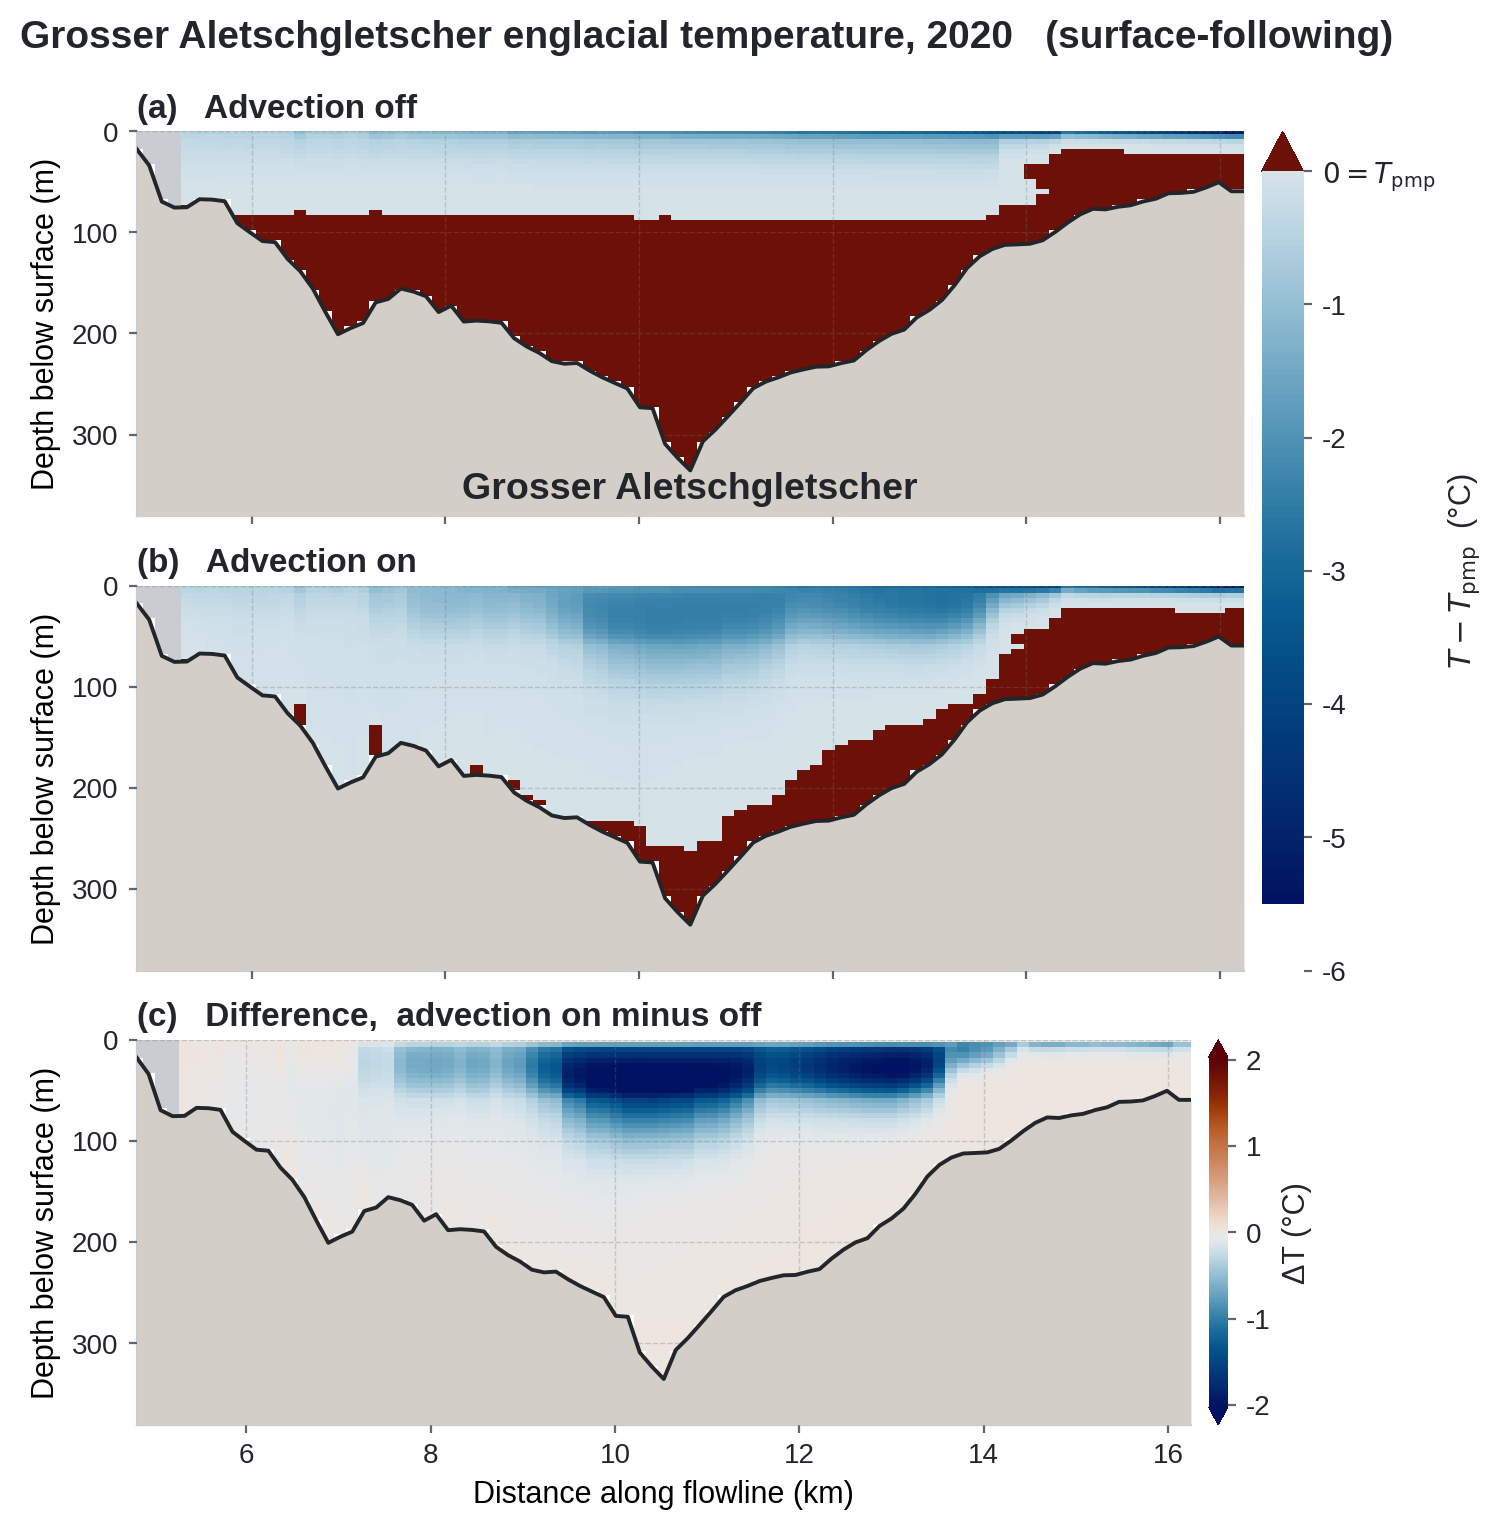

In [10]:
def depth_figure(sections, year, name=None, figsize=(7.6, 8.4), view=None,
                 diff_pct=98.0):
    name = name or NAME          # see advection_figure: a NAME default binds at def time
    view = view or TEMPERATURE_VIEW
    key  = 'd_homologous' if view == 'homologous' else 'd_values'
    off, on = sections['off'], sections['on']
    diff = on['d_values'] - off['d_values']

    ice = on['has_ice']
    x, d = on['dist'], on['d_axis']
    xlim = (x[ice].min(), x[ice].max())

    tmin = float(min(off[key].min(), on[key].min()))
    norm_t = Normalize(vmin=np.floor(tmin * 2) / 2, vmax=0.0)
    finite = np.abs(diff.compressed())
    lim = max(round(float(np.percentile(finite, diff_pct)), 2), 0.05) if finite.size else 0.1
    norm_d = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True,
                             gridspec_kw=dict(hspace=0.18))

    def panel(ax, sec, values, cmap, norm, temperate=None):
        if sec['d_unresolved'].any():
            grey = np.ma.masked_where(~sec['d_unresolved'],
                                      np.ones_like(sec['d_unresolved'], float))
            ax.pcolormesh(x, d, grey, cmap=ListedColormap([GREY_ICE]),
                          vmin=0, vmax=1, shading='nearest', zorder=1)
        plotted = np.ma.where(temperate, norm.vmax + 1.0, values) if temperate is not None else values
        m = ax.pcolormesh(x, d, plotted, cmap=cmap, norm=norm, shading='nearest', zorder=2)
        # the bed, as depth = ice thickness
        # A little headroom below the deepest ice, so the bed line is not flush with the
        # axis edge and the glacier name has rock to sit in.
        dbot = d.max() * 1.12
        ax.plot(x[ice], sec['ice_thick'][ice], color=INK, lw=1.4, zorder=5)
        ax.fill_between(x[ice], sec['ice_thick'][ice], dbot,
                        color=GREY_ROCK, zorder=3, linewidth=0)
        ax.grid(True, color='0.45', alpha=0.30, ls='--', lw=0.5, zorder=4)
        ax.set_axisbelow(False)
        ax._sec_dist, ax._sec_bed, ax._sec_ice = x, sec['ice_thick'], ice
        ax.set_ylim(dbot, 0)                         # surface at the top
        ax.set_ylabel('Depth below surface (m)')
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        for side in ('left', 'bottom'):
            ax.spines[side].set_color('#c8ccd0')
        ax.tick_params(colors=INK_SOFT, labelcolor=INK, length=3)
        return m

    m1 = panel(axes[0], off, off[key], CMAP_T, norm_t, off['d_temperate'])
    panel(axes[1], on, on[key], CMAP_T, norm_t, on['d_temperate'])
    m2 = panel(axes[2], on, diff, CMAP_DIFF, norm_d)
    axes[0].set_xlim(*xlim)

    for ax, t in zip(axes, ['(a)   Advection off', '(b)   Advection on',
                            '(c)   Difference,  advection on minus off']):
        ax.set_title(t, loc='left', fontsize=12, fontweight='bold', color=INK, pad=5)
    axes[-1].set_xlabel('Distance along flowline (km)')

    cb0 = fig.colorbar(m1, ax=axes[:2], pad=0.015, fraction=0.045, extend='max')
    cb0.set_label('$T - T_\mathrm{pmp}$  (°C)' if view == 'homologous'
                  else 'Englacial temperature (°C)', color=INK)
    _label_pmp_tick(cb0, view)
    cb2 = fig.colorbar(m2, ax=[axes[2]], pad=0.015, fraction=0.09, extend='both')
    cb2.set_label('ΔT (°C)', color=INK)
    for cb in (cb0, cb2):
        cb.outline.set_visible(False)
        cb.ax.tick_params(colors=INK_SOFT, labelcolor=INK, length=3)

    _label_glacier(axes[0], name)
    _titles(fig, f'{name} englacial temperature, {year}   (surface-following)')
    return fig, axes


fig_depth, _ = depth_figure(sections, YEAR)
plt.show()

### The same velocities, surface-following

Grenzgletscher is 60–300 m of ice spread over 2300 m of relief, so on the elevation axis the
velocity field is a hairline — the shear profile that panel (a) is about cannot be seen at all.
Plotting depth below the surface instead trades the glacier's shape for a legible column, the
same trade section 5b makes for temperature.

The *w* scale is set from the 99th percentile of |*w*|, which on Grenzgletscher is driven by
the steep step near 4 km; most of the glacier sits well inside it.


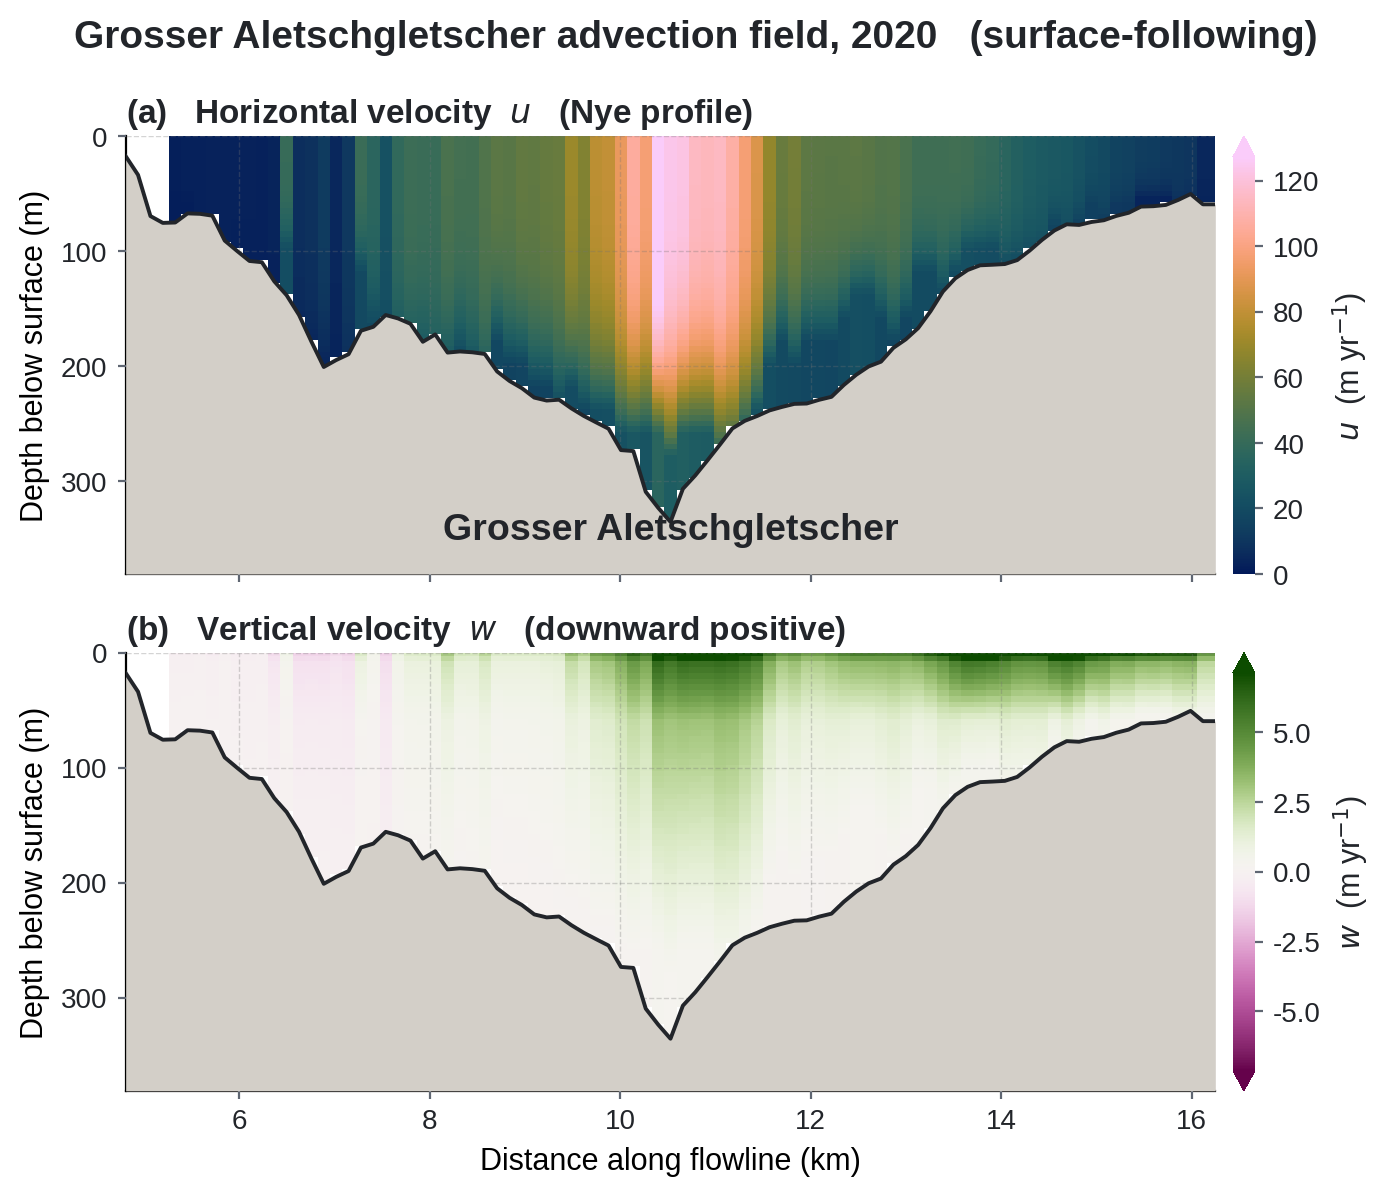

In [11]:
def velocity_depth_figure(vel_sec, sections, year, name=None, figsize=(7.6, 6.2)):
    """u and w on a depth-below-surface axis, for glaciers too thin to read on elevation."""
    name = name or NAME
    su, sw = vel_sec['u'], vel_sec['w']
    on = sections['on']
    ice = on['has_ice']
    x, d = on['dist'], on['d_axis']

    ucol = su['d_values'].compressed()
    wcol = np.abs(sw['d_values'].compressed())
    norm_u = Normalize(vmin=0.0, vmax=max(round(float(np.nanpercentile(ucol, 99)), 1), 0.1))
    wlim = max(round(float(np.nanpercentile(wcol, 99)), 2), 0.05)
    norm_w = TwoSlopeNorm(vmin=-wlim, vcenter=0.0, vmax=wlim)

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True,
                             gridspec_kw=dict(hspace=0.18))

    def panel(ax, sec, cmap, norm):
        m = ax.pcolormesh(x, d, sec['d_values'], cmap=cmap, norm=norm,
                          shading='nearest', zorder=2)
        dbot = d.max() * 1.12
        ax.plot(x[ice], on['ice_thick'][ice], color=INK, lw=1.4, zorder=5)
        ax.fill_between(x[ice], on['ice_thick'][ice], dbot, color=GREY_ROCK,
                        zorder=3, linewidth=0)
        ax.grid(True, color='0.45', alpha=0.30, ls='--', lw=0.5, zorder=4)
        ax.set_axisbelow(False)
        ax.set_ylim(dbot, 0)                       # surface at the top
        ax.set_ylabel('Depth below surface (m)')
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        ax.tick_params(colors=INK_SOFT, labelcolor=INK, length=3)
        return m

    mu = panel(axes[0], su, CMAP_U, norm_u)
    mw = panel(axes[1], sw, CMAP_W, norm_w)
    axes[0].set_xlim(x[ice].min(), x[ice].max())

    for ax, t in zip(axes, ['(a)   Horizontal velocity  $u$   (Nye profile)',
                            '(b)   Vertical velocity  $w$   (downward positive)']):
        ax.set_title(t, loc='left', fontsize=12, fontweight='bold', color=INK, pad=5)
    axes[-1].set_xlabel('Distance along flowline (km)')

    cbu = fig.colorbar(mu, ax=[axes[0]], pad=0.015, fraction=0.06, extend='max')
    cbu.set_label('$u$  (m yr$^{-1}$)', color=INK)
    cbw = fig.colorbar(mw, ax=[axes[1]], pad=0.015, fraction=0.06, extend='both')
    cbw.set_label('$w$  (m yr$^{-1}$)', color=INK)
    for cb in (cbu, cbw):
        cb.outline.set_visible(False)
        cb.ax.tick_params(colors=INK_SOFT, labelcolor=INK, length=3)

    _label_glacier(axes[0], name, buffer=0.10)
    _titles(fig, f'{name} advection field, {year}   (surface-following)', top=0.945)
    return fig, axes


fig_vel_depth, _ = velocity_depth_figure(vel_sec, sections, YEAR)
plt.show()


## 6 — The number for the slide

Slide 7 reserves a line for a single sentence:

> *"On Aletsch, neglecting advection changes modelled englacial temperature by X °C at Y m depth."*

Two numbers can fill that blank and they are far apart, so the cell reports both:

* the **largest** single-band change, which is the headline but rests on one band, and
* the **mean absolute** change over all bands at that depth, which is what the figure
  actually looks like.

The depth is chosen by the mean, not the maximum — an extreme in one band is a weaker basis
for a claim about the glacier than a shift the whole profile shares.

In [12]:
def advection_effect(fields, year, glacier_name=NAME):
    fo, fa = fields['off'], fields['on']
    yo = int(np.where(fo['years'] == year)[0][0])
    ya = int(np.where(fa['years'] == year)[0][0])

    bands = np.intersect1d(fo['elev'], fa['elev'])
    d = (fa['T'][ya][np.searchsorted(fa['elev'], bands)]
         - fo['T'][yo][np.searchsorted(fo['elev'], bands)])

    rows = []
    for j, z in enumerate(fa['depths']):
        col = d[:, j][np.isfinite(d[:, j])]
        if col.size == 0:
            continue
        rows.append(dict(depth=z, largest=col[int(np.argmax(np.abs(col)))],
                         mean_abs=np.mean(np.abs(col)),
                         p95=np.percentile(np.abs(col), 95), n=col.size))

    print(f'{glacier_name}, {year}   (advection on − off)\n' + '-' * 60)
    print(f'{"depth":>7}  {"largest":>9}  {"mean |dT|":>10}  {"p95 |dT|":>9}  {"bands":>6}')
    best = max(rows, key=lambda r: r['mean_abs'])
    for r in rows:
        print(f'{r["depth"]:7.0f}  {r["largest"]:+9.2f}  {r["mean_abs"]:10.2f}'
              f'  {r["p95"]:9.2f}  {r["n"]:6d}' + ('  <--' if r is best else ''))

    hottest = max(rows, key=lambda r: abs(r['largest']))
    print('\nfor the slide, pick one:')
    print(f'  typical  -  advection shifts englacial temperature by '
          f'{best["mean_abs"]:.1f} \u00b0C on average at {best["depth"]:.0f} m depth')
    print(f'  extreme  -  by up to {abs(hottest["largest"]):.1f} \u00b0C at '
          f'{hottest["depth"]:.0f} m depth, in a single elevation band')

    for m in ('off', 'on'):
        r = basal_regime(sections[m])
        known = r >= 0
        if known.any():
            print(f'  basal    -  {m:7s}: {100*np.mean(r[known]==1):.0f}% of the '
                  f'diagnosable bed is temperate ({known.sum()} cells)')
    return rows

_ = advection_effect(fields, YEAR)

Grosser Aletschgletscher, 2020   (advection on − off)
------------------------------------------------------------
  depth    largest   mean |dT|   p95 |dT|   bands
      0      +0.00        0.00       0.00     213
      1      -0.27        0.15       0.25     212
      2      -0.52        0.30       0.49     212
      3      -0.69        0.40       0.63     212
      4      -0.83        0.48       0.71     212
      5      -0.94        0.54       0.87     212
      6      -1.09        0.58       1.04     212
      7      -1.29        0.62       1.22     212
      8      -1.49        0.64       1.40     212
      9      -1.69        0.65       1.58     212  <--
     14      -1.89        0.64       1.76     212
     19      -2.04        0.64       1.90     212
     24      -2.13        0.64       2.02     212
     29      -2.15        0.63       2.10     212
     34      -2.22        0.60       2.15     212
     39      -2.26        0.57       2.16     212
     44      -2.25        0.52

## 8 — Both glaciers: temperature and advection field

Aletsch and Grenzgletscher, side by side, from runs with identical physics. Reassigning the
module-level names and calling the same functions is enough — every figure function reads
`NAME` at call time.

RGI7 outline `01225` covers the whole Gorner complex; the flowline the model builds follows
its longest and highest branch, Colle Gnifetti down to the tongue, which is **Grenzgletscher**.
The glenglat calibration list names the same outline "Gornergletscher" — same ice, different
naming convention.

**Grenzgletscher was chosen because it should have a large cold high-altitude firn area**, and
because 21 glenglat boreholes sit on it between 3810 and 4480 m, so there are observations to
check against. The model does not reproduce that cold firn. At 4495 m it gives −5.0 °C at 1 m
but only −0.33 °C at 24 m, and 17 % of the resolved ice above 3800 m sits exactly at the
pressure melting point. Colle Gnifetti, on this glacier at ~4450 m, is measured at roughly
−12 °C.

The mechanism is latent heat: meltwater is allowed to percolate to the firn/ice transition set
by Herron–Langway and refreeze there, which is enough to carry the whole column to the melting
point. At 4400 m there is almost no melt to redistribute, and refreezing should be confined to
the top few metres. This is the same defect the Tier-3 grid search already pointed at — 12 of
24 glaciers pinned `perm_frac` on its lowest sampled value, i.e. the calibration was pushing
against the bound, asking for less percolation than the model allows.

So Grenzgletscher is an excellent *diagnostic* and a poor *showcase*: it demonstrates the bias
rather than a captured cold–temperate transition.

The second figure of each pair is the **advection field** — the same *u* and *w* panels as
section 5, on each glacier's own cross-section. Grenzgletscher is the steeper and thinner of
the two, so its velocities are read on their own colour scale, not Aletsch's.


Grosser Aletschgletscher: 72% of the diagnosable bed is temperate (85 cells)   |   u <= 127 m/yr, |w| <= 6.2 m/yr  (99th percentile)


Grenzgletscher: 51% of the diagnosable bed is temperate (75 cells)   |   u <= 110 m/yr, |w| <= 22.4 m/yr  (99th percentile)


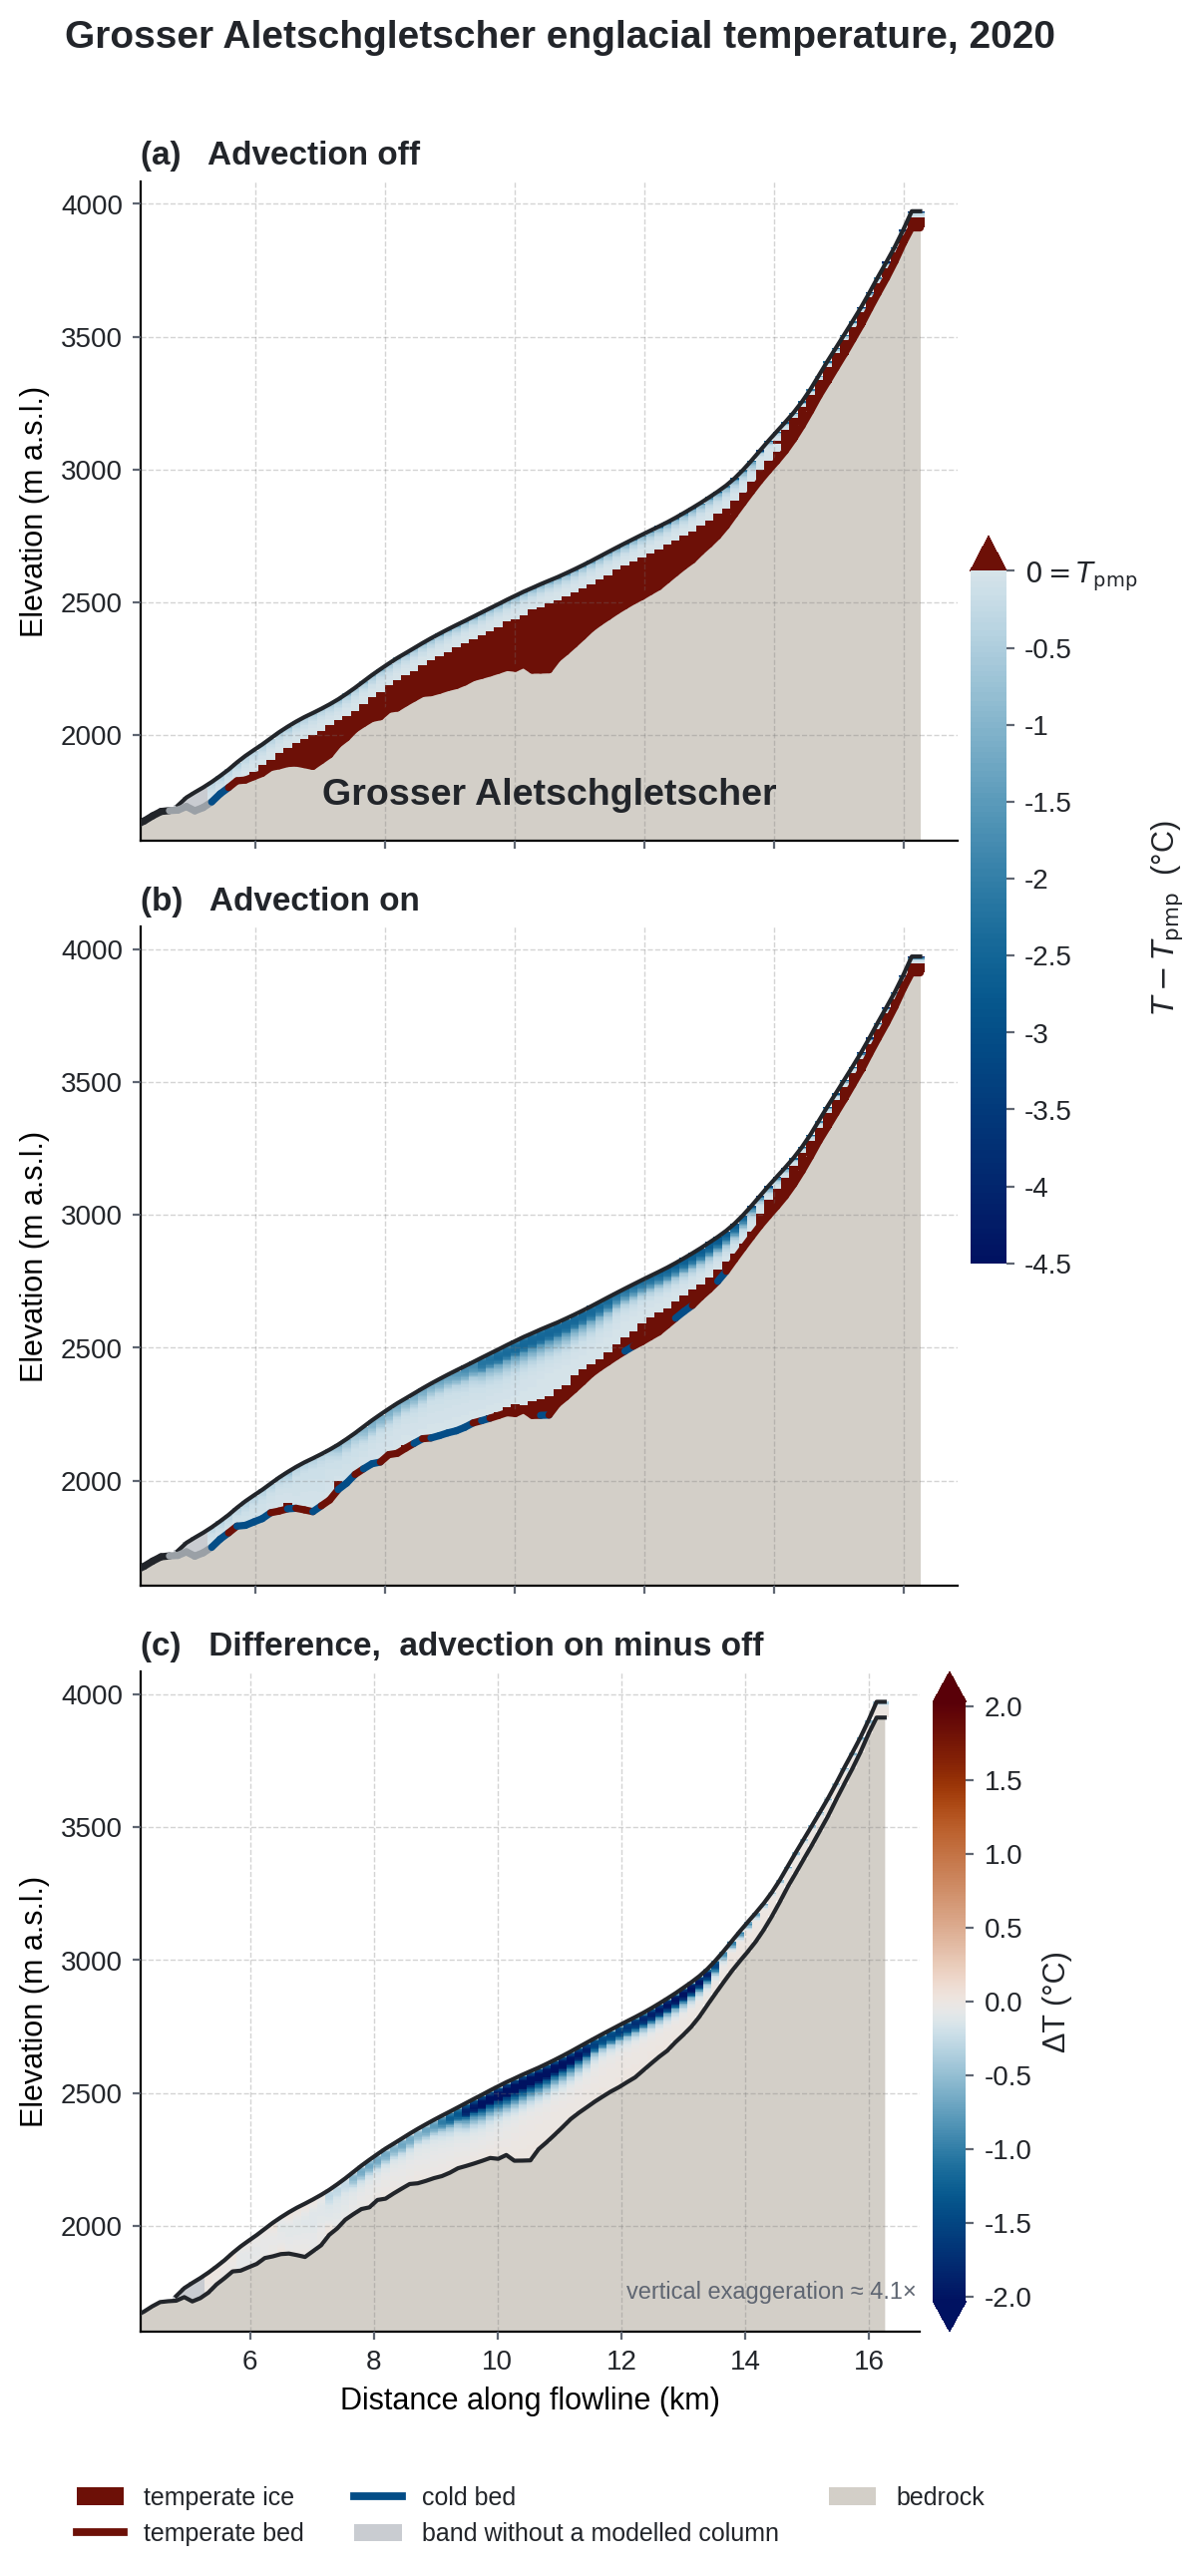

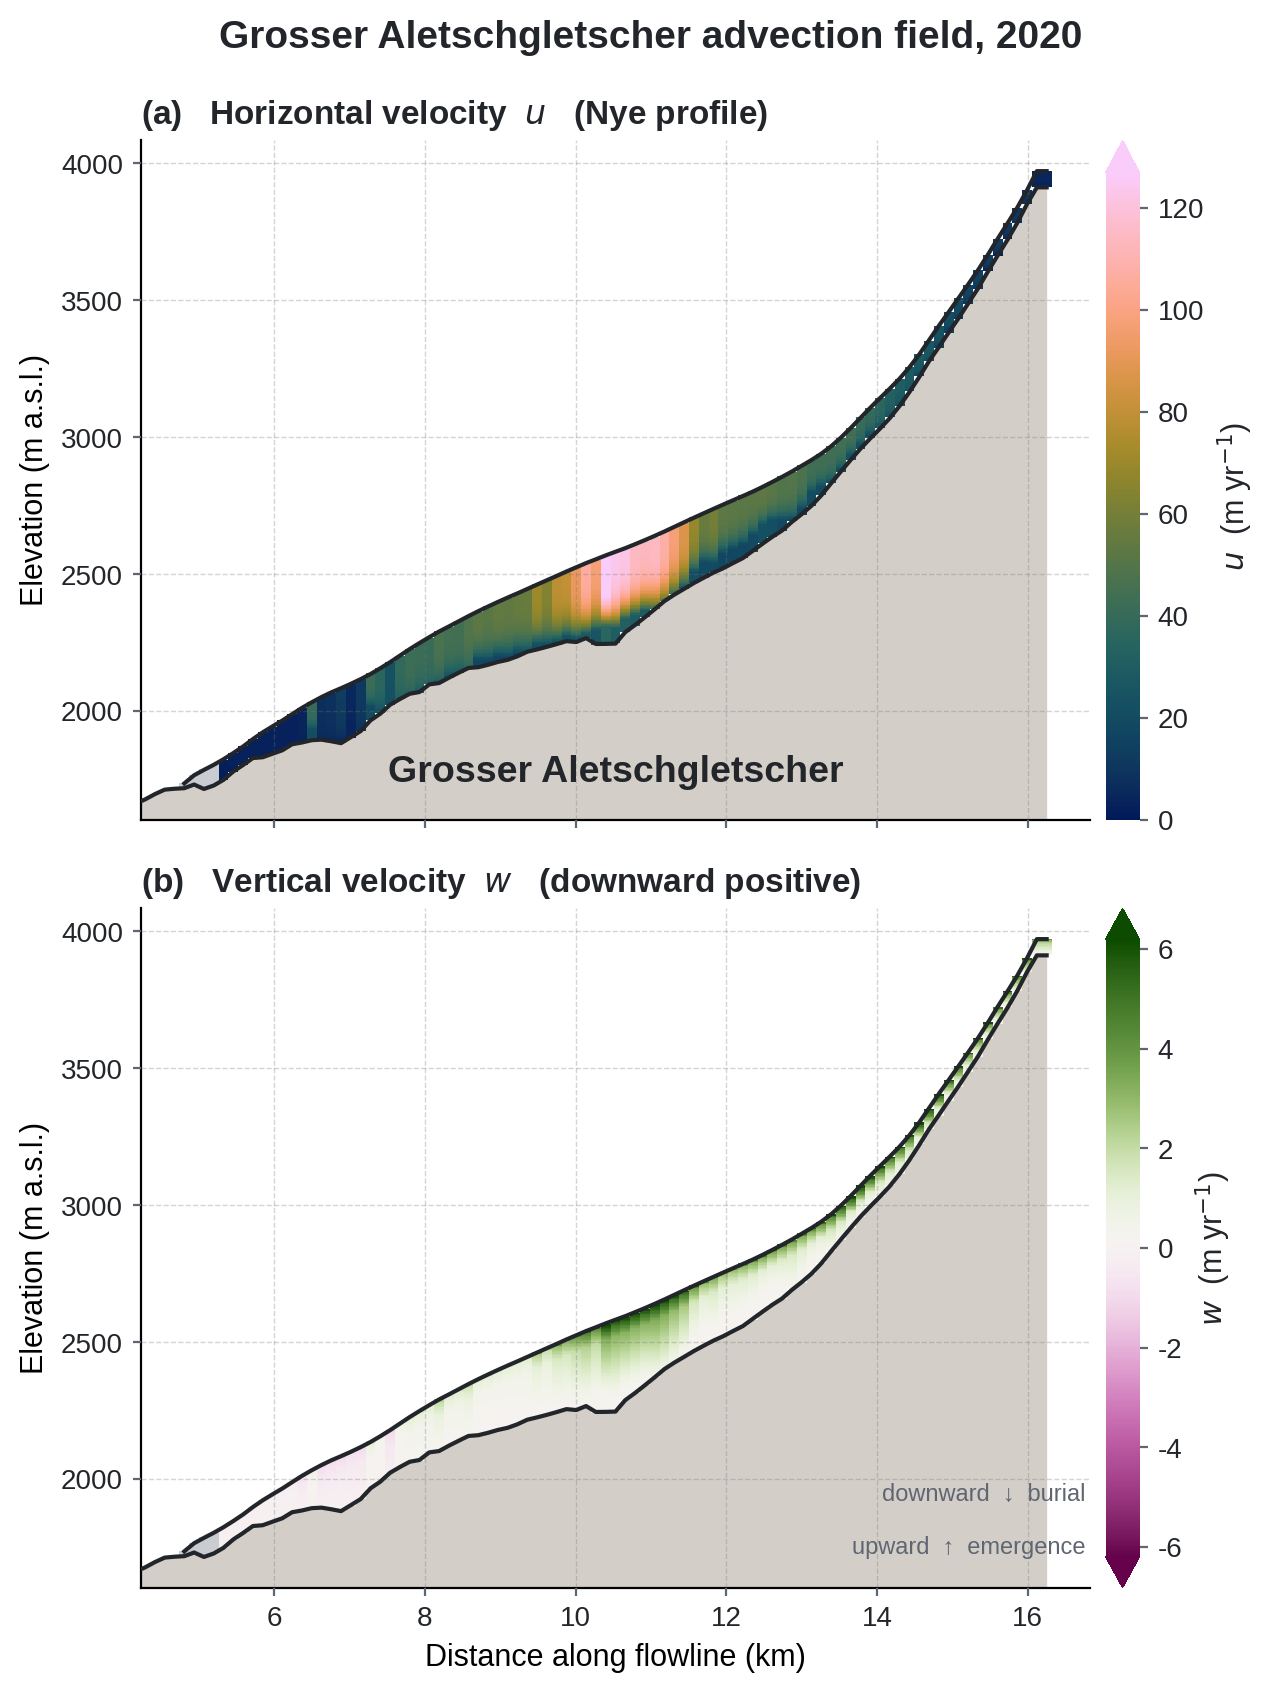

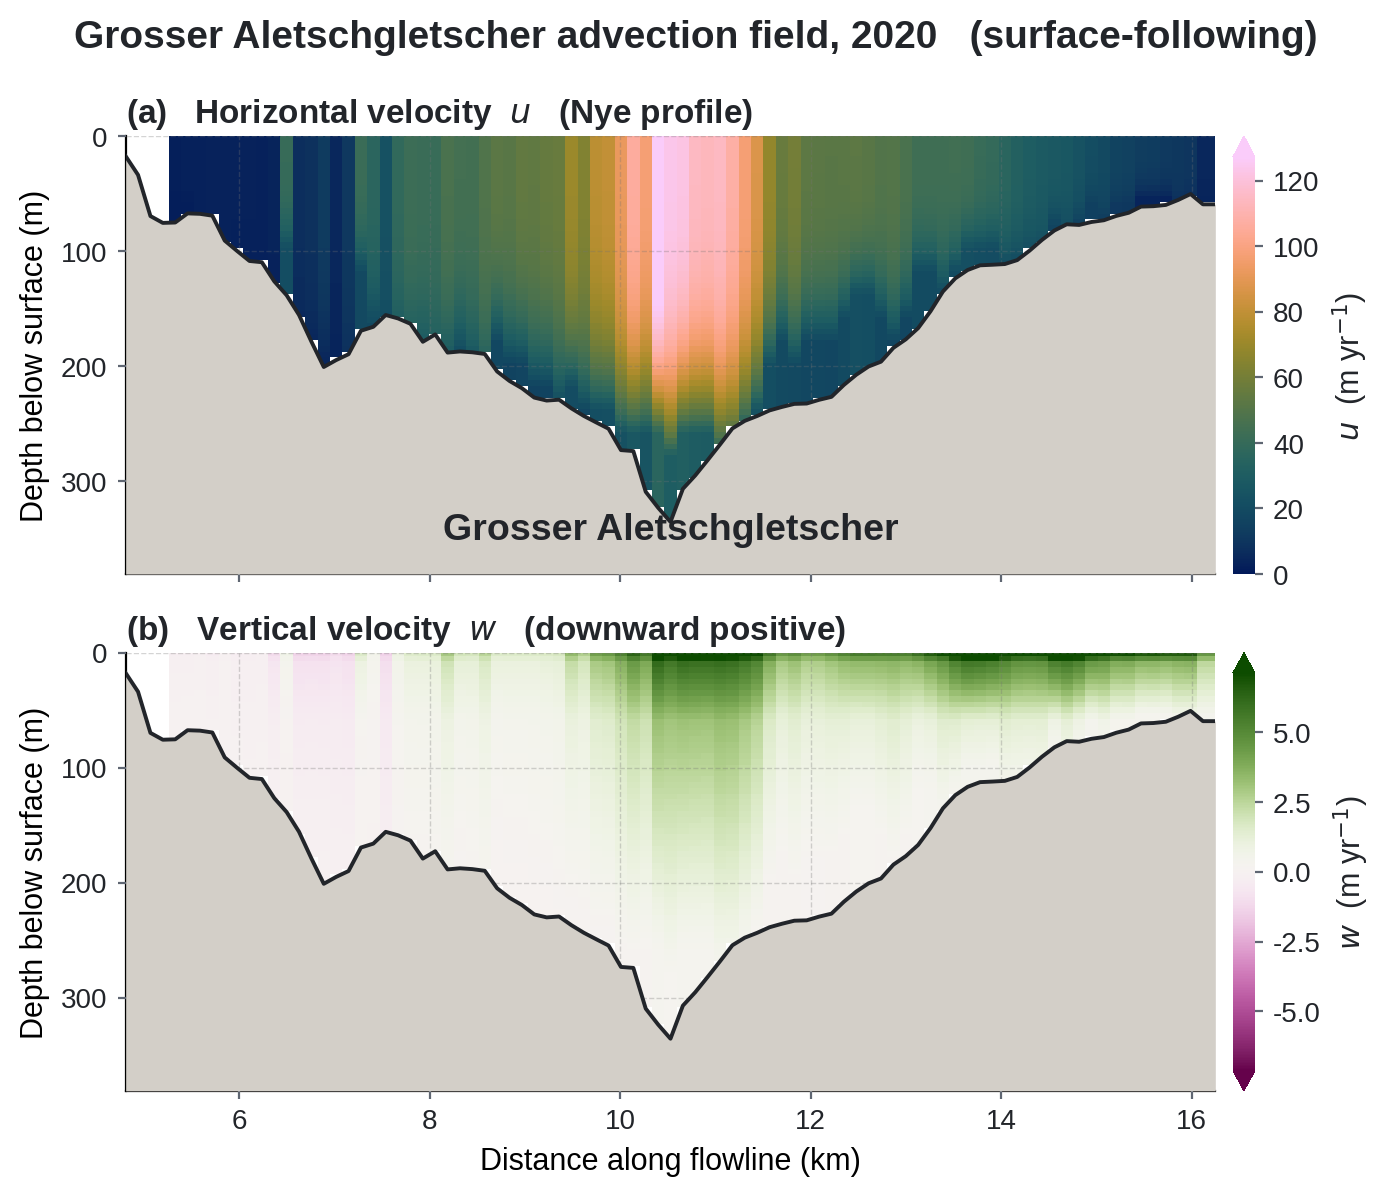

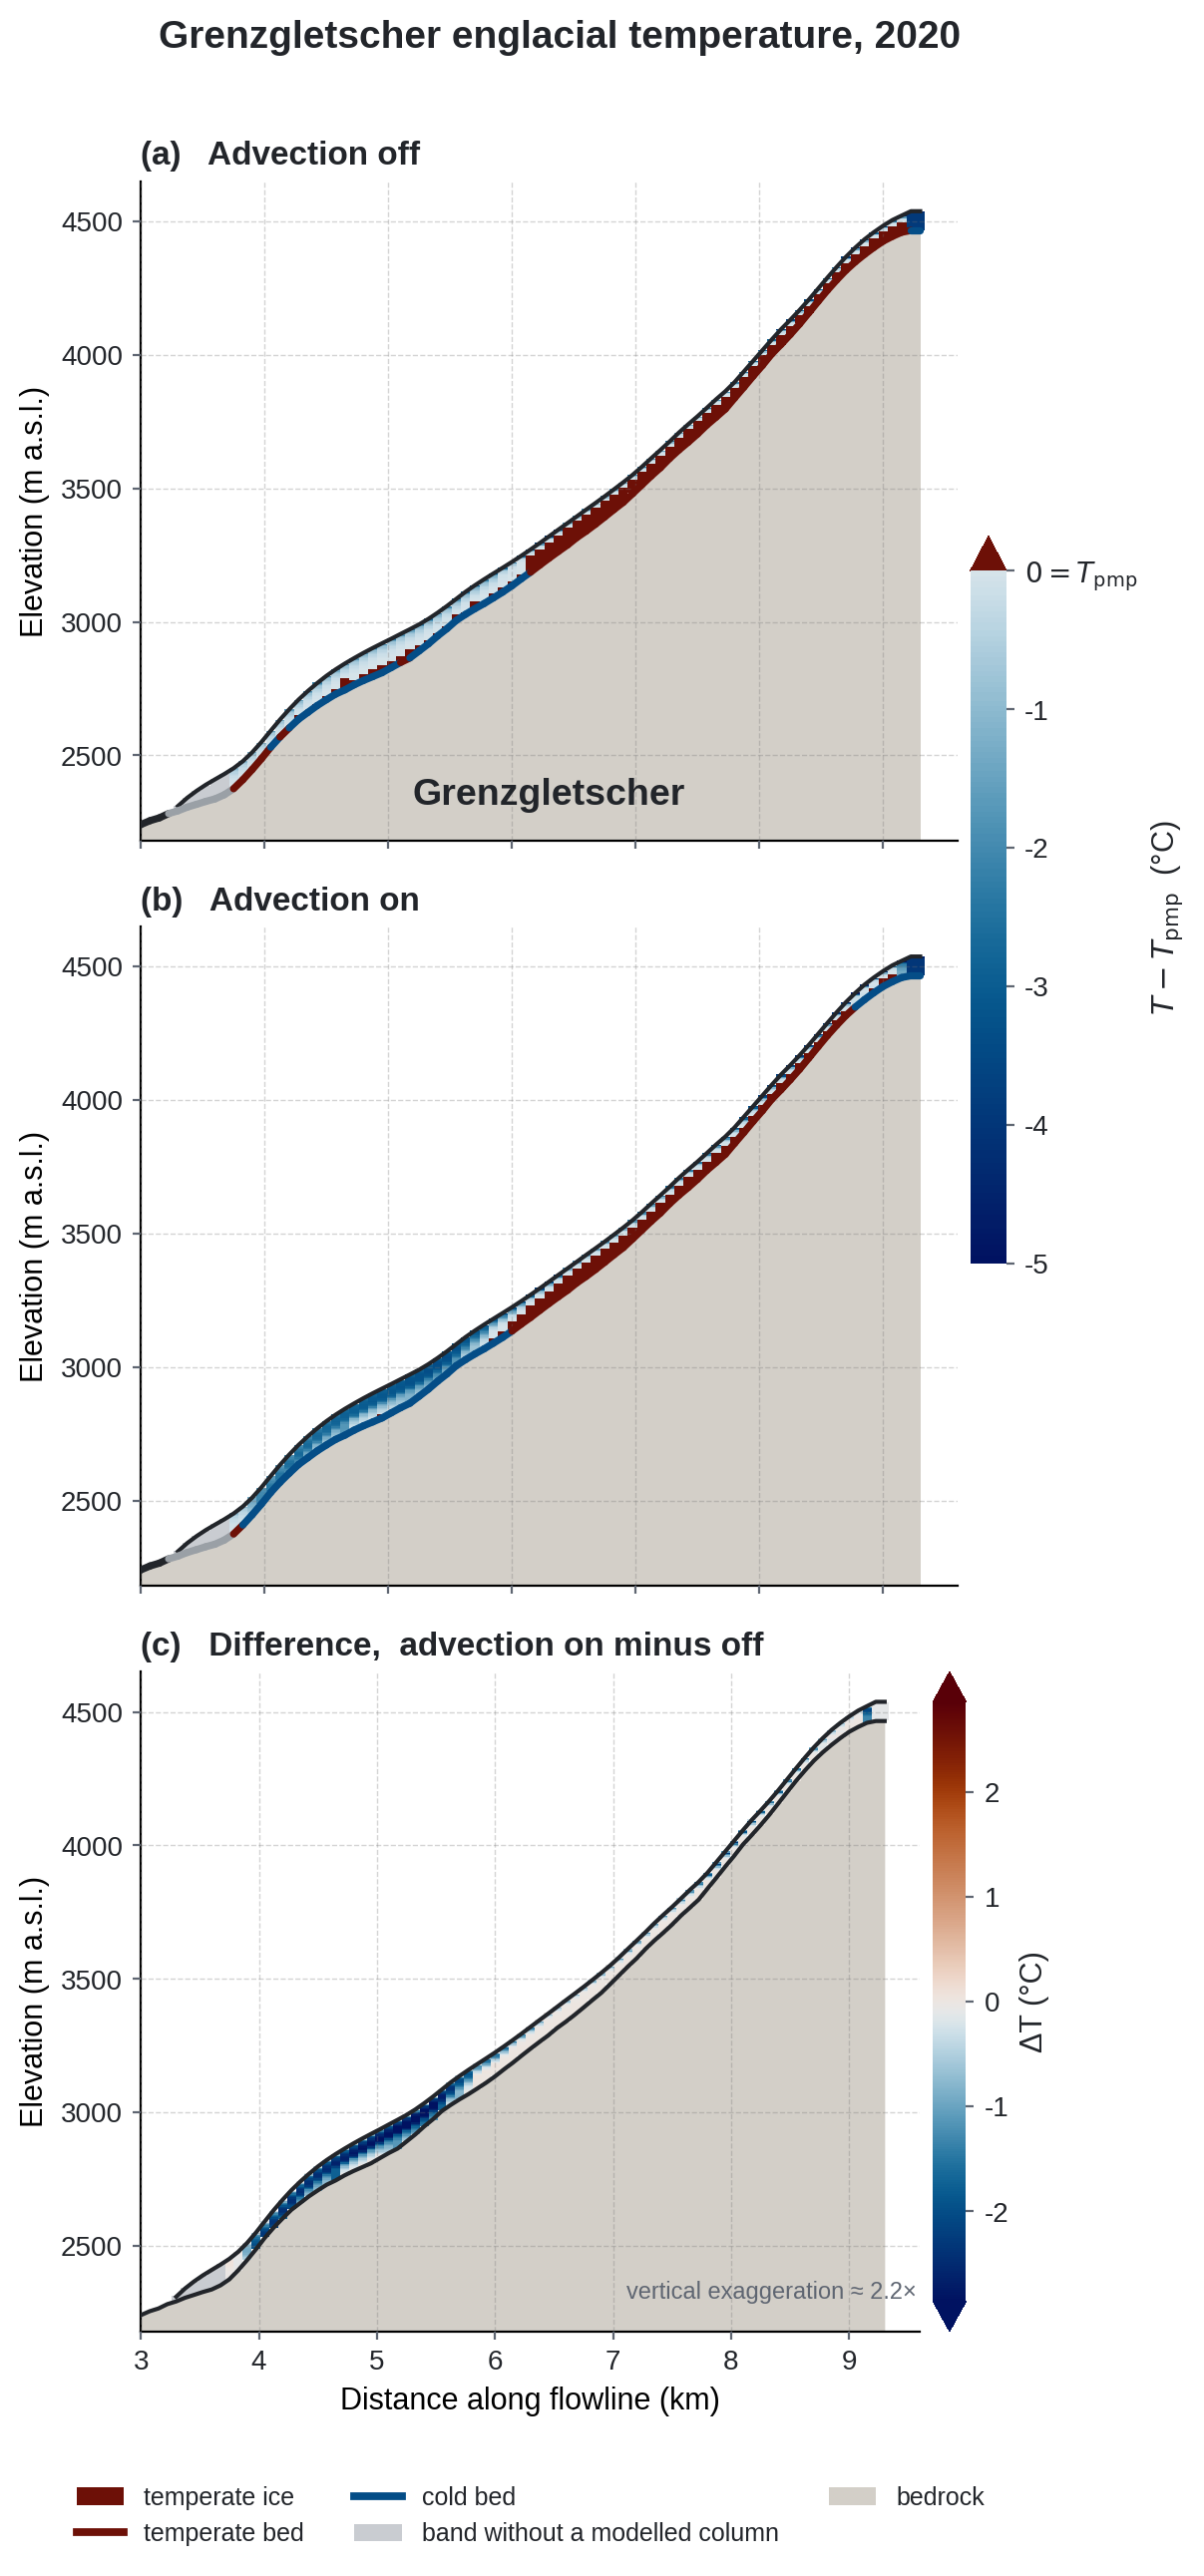

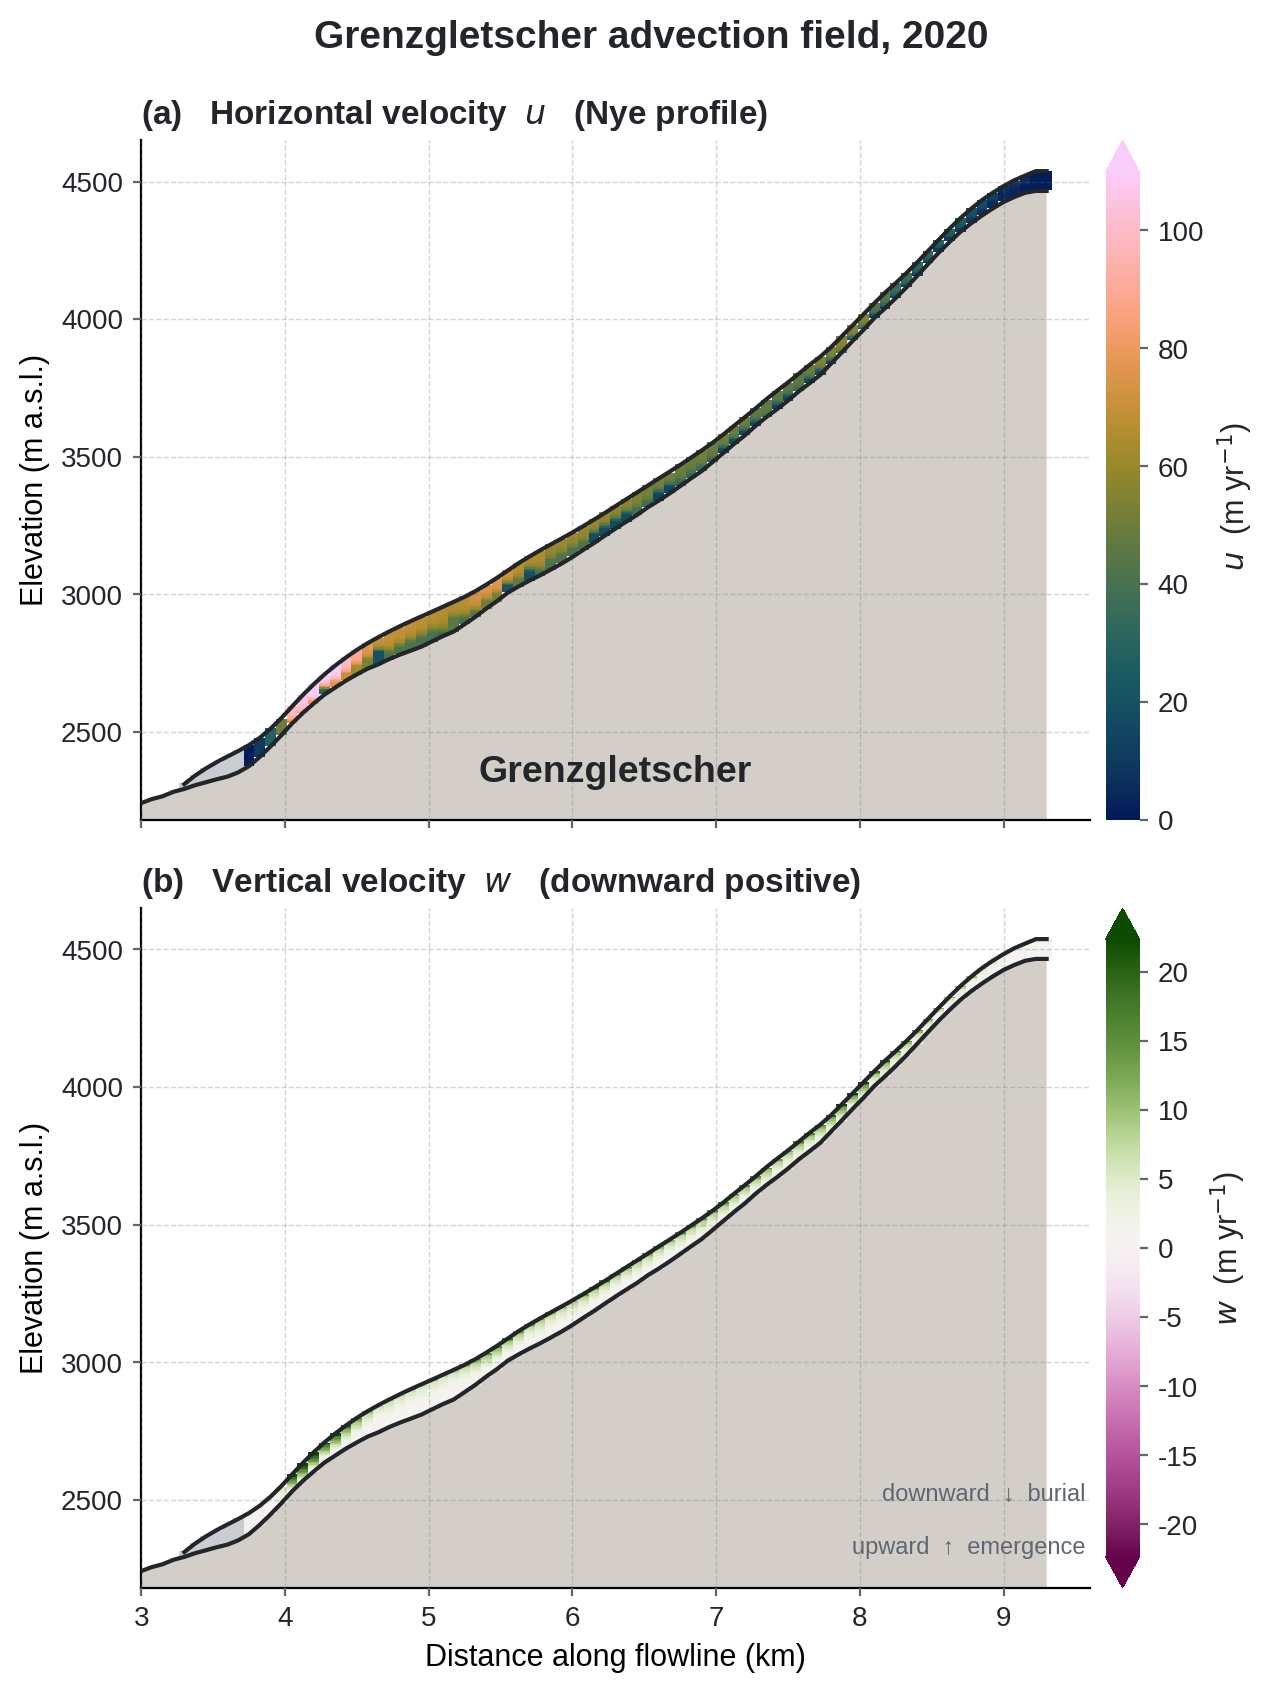

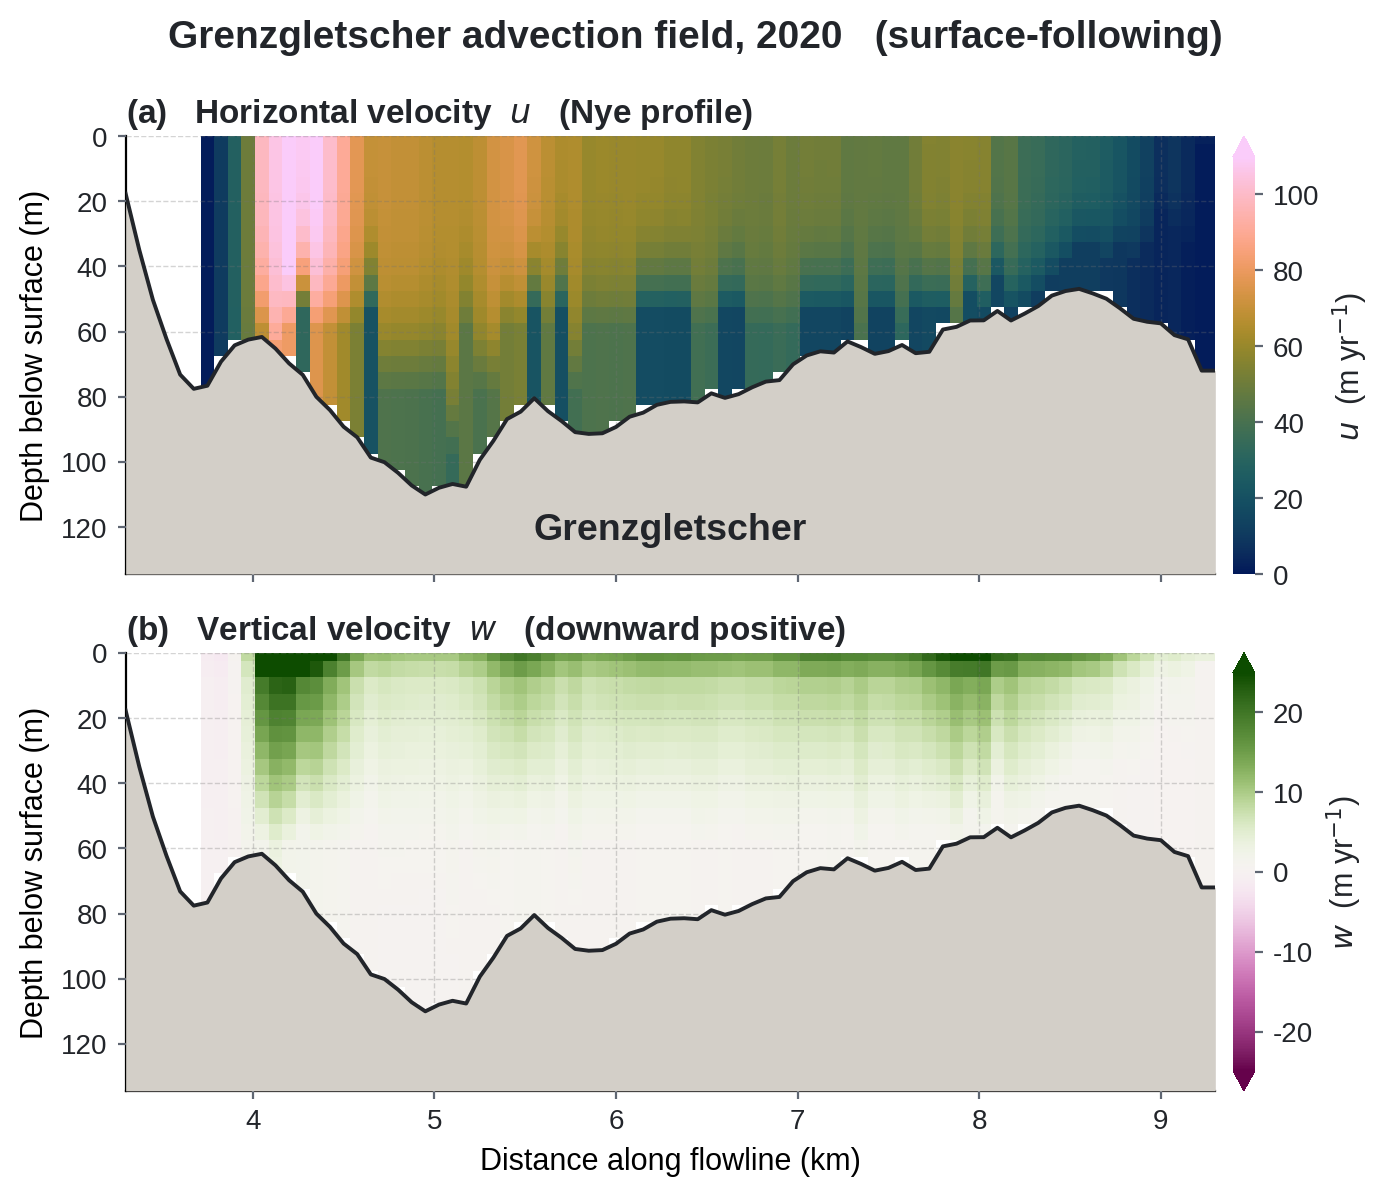

In [13]:
figs, vfigs, vdfigs = {}, {}, {}
for _gl in ('02596', '01225'):
    GLACIER = _gl
    SETUP   = WHERE[_gl]
    MEMBER_ON, MEMBER_OFF, SETUP_LABEL = SETUPS[SETUP]
    NAME, GLACIER_INFO = GLACIERS[_gl]
    MEMBERS = {'off': MEMBER_OFF, 'on': MEMBER_ON}

    fields, grids = {}, {}
    for _k, _m in MEMBERS.items():
        _d = member_dir(_m)
        fields[_k] = read_temp_field(_d / 'firnice_temperature' / f'temp_field_{_gl}.dat')
        grids[_k]  = read_flowgrid(flowgrid_path(_m, _gl))
    sections = {m: cross_section(fields[m], grids[m], YEAR, key='T', temperate_from='T')
                for m in ('off', 'on')}

    # velocities are written only by the advection-on member
    _vel  = read_vel_field(member_dir(MEMBER_ON) / 'firnice_temperature'
                           / f'vel_field_{_gl}.dat')
    _vsec = {k: cross_section(_vel, grids['on'], YEAR, key=k) for k in ('u', 'w')}

    figs[_gl],  _ = advection_figure(sections, YEAR)
    vfigs[_gl],  _ = velocity_figure(_vsec, sections, YEAR)
    vdfigs[_gl], _ = velocity_depth_figure(_vsec, sections, YEAR)
    _r = basal_regime(sections['on'])
    _known = _r >= 0
    print(f'{NAME}: {100*np.mean(_r[_known]==1):.0f}% of the diagnosable bed is temperate '
          f'({_known.sum()} cells)   |   u <= '
          f"{np.nanpercentile(_vsec['u']['values'].compressed(), 99):.0f} m/yr, "
          f"|w| <= {np.nanpercentile(np.abs(_vsec['w']['values'].compressed()), 99):.1f} m/yr"
          '  (99th percentile)')
plt.show()

## 9 — Saving

Nothing is written to disk unless you ask for it. Flip `SAVE` to `True` and set a directory
when the figures are final. `savefig.dpi` is already 400.

In [14]:
SAVE = False
OUTDIR = Path.home()

if SAVE:
    for f, stem in ((fig_depth,      'ggmw2026_depth_view'),
                    (figs['02596'],  'ggmw2026_aletsch_cross_section'),
                    (figs['01225'],  'ggmw2026_grenz_cross_section'),
                    (vfigs['02596'], 'ggmw2026_aletsch_advection_field'),
                    (vfigs['01225'], 'ggmw2026_grenz_advection_field'),
                    (vdfigs['01225'], 'ggmw2026_grenz_advection_field_depth')):
        for ext in ('pdf', 'png'):
            p = OUTDIR / f'{stem}.{ext}'
            f.savefig(p, bbox_inches='tight')
            print('written', p)
else:
    print('SAVE is False - nothing written')

SAVE is False - nothing written


## 10 — Do the boreholes support the advection cooling?

The workshop question was where the cold in Aletsch's ablation zone comes from, given that its
accumulation area is wet firn and should be sending *warm* ice down. Four glenglat boreholes sit
on **Jungfraufirn**, Aletsch's accumulation basin, at 3410–3630 m — exactly the source region —
drilled by Suter (2001) and re-measured through 1991, so there is a seasonal sequence rather
than a single snapshot.

The model is sampled in the **same calendar month** as each measurement, so season is controlled
for. Two caveats: the observations are from 1991 and the model state is 2020, and borehole 679
(3630 m) has only a March profile and sits *100 m below a bergschrund*, which is a local cold
anomaly rather than a representative site.

In [15]:
import pandas as pd, glob, os, re

GLENGLAT = Path('/home/jabeer/projects/glogemflow_development/glogemflow_icetemp/glenglat/data')
ALETSCH_BOREHOLES = [30, 31, 32, 678, 679]     # Jungfraufirn, Suter (2001)

def read_glenglat(ids=ALETSCH_BOREHOLES):
    bh = pd.read_csv(GLENGLAT / 'borehole.csv')
    pr = pd.read_csv(GLENGLAT / 'profile.csv')
    me = pd.read_csv(GLENGLAT / 'measurement.csv')
    # profile ids restart within each borehole, so the join needs both keys
    d = me[me.borehole_id.isin(ids)].merge(
        pr[['borehole_id', 'id', 'date_min']].rename(columns={'id': 'profile_id'}),
        on=['borehole_id', 'profile_id'])
    d['elev']  = d.borehole_id.map(bh.set_index('id').elevation)
    d['month'] = pd.to_datetime(d.date_min).dt.month
    return d

def read_model_profiles(member, glacier=GLACIER, year=YEAR):
    """Monthly modelled profiles at the glenglat borehole elevations."""
    d = member_dir(member) / 'firnice_temperature'
    out = {}
    for f in sorted(d.glob(f'temp_ID*_{glacier}.dat')):
        lines = f.read_text().splitlines()
        elev   = int(re.findall(r'\d+', lines[0])[0])
        depths = np.array([float(x) for x in lines[1].split()[2:]])
        a = np.loadtxt(f, skiprows=2)
        a = a[a[:, 0] == year]
        # prepare_output_firnicetemp.pro writes one depth label too few: the header loops
        # i=1..total(fit_layers)-1 while the data row prints tl_fit[1:total(fit_layers)].
        # Values align with the labels from the top, so trim the unlabelled last column.
        T = np.where(a[:, 2:] > -98, a[:, 2:], np.nan)[:, :len(depths)]
        out[elev] = dict(depth=depths, month=a[:, 1].astype(int), T=T)
    return out

# Pin this section to Aletsch explicitly. The both-glaciers loop above leaves the module
# globals (GLACIER, MEMBER_ON, ...) pointing at whichever glacier it finished with, so
# relying on them here would silently read Grenzgletscher's boreholes instead.
BH_GLACIER = '02596'
BH_ON, BH_OFF, _ = SETUPS[WHERE[BH_GLACIER]]

obs      = read_glenglat()
mod_on   = read_model_profiles(BH_ON,  BH_GLACIER)
mod_off  = read_model_profiles(BH_OFF, BH_GLACIER)
print(f'{obs.borehole_id.nunique()} boreholes, {len(obs)} measurements, '
      f'{sorted(obs.month.unique())} = sampling months of 1991')
print('modelled profile elevations:', sorted(mod_on))

5 boreholes, 104 measurements, [np.int32(3), np.int32(5), np.int32(7), np.int32(8)] = sampling months of 1991
modelled profile elevations: [3405, 3525, 3535, 3625]


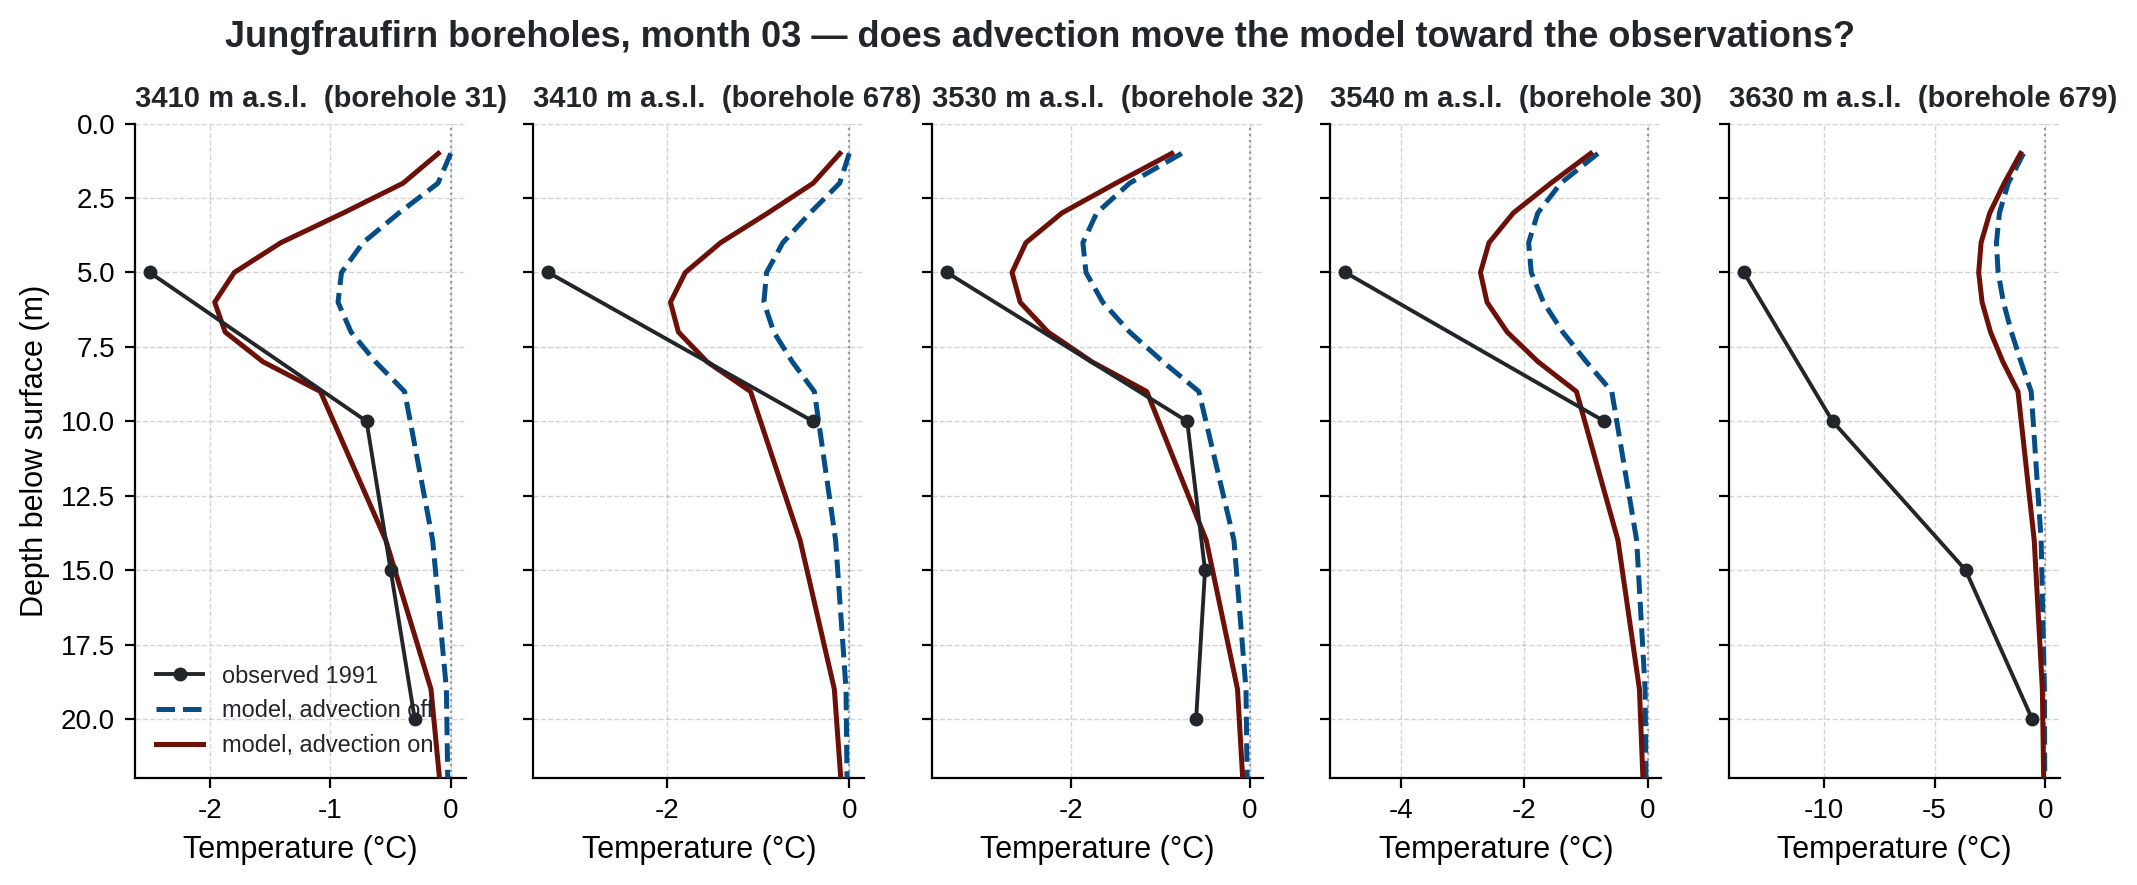

bias and RMSE against the Jungfraufirn boreholes (all months, 5-20 m):
  advection off:  bias +1.13 °C   RMSE 2.36 °C   n=60
  advection  on:  bias +0.98 °C   RMSE 2.20 °C   n=60


In [16]:
def borehole_figure(month=3, zmax=22, figsize=(10.5, 4.2)):
    sites = sorted(obs.groupby(['elev', 'borehole_id']).groups, key=lambda t: t[0])
    sites = [s for s in sites if month in obs[(obs.elev == s[0]) &
                                              (obs.borehole_id == s[1])].month.values]
    fig, axes = plt.subplots(1, len(sites), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (e, bid) in zip(axes, sites):
        g = obs[(obs.elev == e) & (obs.borehole_id == bid) & (obs.month == month)].sort_values('depth')
        ax.plot(g.temperature, g.depth, 'o-', color=INK, ms=4, lw=1.4,
                label='observed 1991', zorder=4)
        ke = min(mod_on, key=lambda k: abs(k - e))
        for src, col, ls, lab in ((mod_off, COL_COLD, '--', 'model, advection off'),
                                  (mod_on,  COL_TEMPERATE, '-', 'model, advection on')):
            m = src[ke]; r = np.where(m['month'] == month)[0]
            if not len(r):
                continue
            ax.plot(m['T'][r[0]], m['depth'], ls, color=col, lw=1.8, label=lab, zorder=3)
        ax.set_title(f'{e:.0f} m a.s.l.  (borehole {bid})', fontsize=10.5,
                     fontweight='bold', color=INK, loc='left')
        ax.set_ylim(zmax, 0)
        ax.axvline(0, color='0.6', lw=0.8, ls=':')
        ax.grid(True, color='0.45', alpha=0.30, ls='--', lw=0.5)
        ax.set_xlabel('Temperature (°C)')
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
    axes[0].set_ylabel('Depth below surface (m)')
    axes[0].legend(loc='lower left', fontsize=8.5, frameon=False, labelcolor=INK)
    fig.text(0.5, 1.0, f'Jungfraufirn boreholes, month {month:02d} — '
                       f'does advection move the model toward the observations?',
             ha='center', va='bottom', fontsize=13, fontweight='bold', color=INK)
    fig.tight_layout()
    return fig

fig_bh = borehole_figure(month=3)
plt.show()

# how much of the observed cold does each member capture?
rows = []
for (e, bid), g in obs.groupby(['elev', 'borehole_id']):
    ke = min(mod_on, key=lambda k: abs(k - e))
    for mo, gg in g.groupby('month'):
        gg = gg.sort_values('depth')
        for z in (5, 10, 15, 20):
            o = np.interp(z, gg.depth, gg.temperature, left=np.nan, right=np.nan)
            if not np.isfinite(o):
                continue
            j = int(np.argmin(np.abs(mod_on[ke]['depth'] - z)))
            for src, lab in ((mod_off, 'off'), (mod_on, 'on')):
                r = np.where(src[ke]['month'] == mo)[0]
                if len(r):
                    rows.append((lab, e, mo, z, o, src[ke]['T'][r[0], j]))
r = pd.DataFrame(rows, columns=['member', 'elev', 'month', 'depth', 'obs', 'mod'])
r['err'] = r['mod'] - r['obs']
print('bias and RMSE against the Jungfraufirn boreholes (all months, 5-20 m):')
for lab, g in r.groupby('member'):
    print(f'  advection {lab:>3}:  bias {g.err.mean():+.2f} °C   '
          f'RMSE {np.sqrt((g.err**2).mean()):.2f} °C   n={len(g)}')